# Diagnóstico de Diabetes com Machine Learning — Estudo Comparativo entre Duas Bases

## Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs

### Contexto do Problema

O diabetes é uma das doenças crônicas mais prevalentes do mundo e está associado a múltiplos fatores: clínicos (glicemia, HbA1c, IMC, pressão, colesterol), comportamentais (tabagismo, sedentarismo, alimentação) e sociais (acesso a cuidados, renda, educação). Quanto mais cedo for identificado o risco, melhores as chances de evitar complicações cardiovasculares, renais e oculares.

O notebook anterior (`02_diabetes.ipynb`) trabalhou com o **Pima Indians Diabetes Dataset**, que tem apenas 768 amostras e 8 features clínicas. Para ampliar essa análise, aqui usamos **duas bases novas, mais ricas** e em paralelo:

1. **BRFSS 2015 — Diabetes Health Indicators** (versão balanceada 50/50): 70.692 amostras e 21 features. Foca em **hábitos de vida, acesso à saúde e dados sociodemográficos**, além de indicadores clínicos autorrelatados.
2. **Diabetes Prediction Dataset** (Kaggle, 2023): 100.000 amostras e 8 features. Tem menos colunas, mas inclui **HbA1c e glicemia**, que são dos indicadores clínicos mais fortes para diabetes.

### Objetivo

Treinar os mesmos três modelos (Regressão Logística, Árvore de Decisão e KNN) em ambas as bases, comparando:

- Qual base produz modelos com melhor capacidade de triagem?
- Features comportamentais e sociais (BRFSS) rivalizam com features clínicas diretas (Prediction)?
- Quais fatores de risco cada base destaca via Feature Importance e SHAP?

Reforçamos desde o início: o modelo é **ferramenta de apoio**. A decisão final de diagnóstico é sempre do(a) médico(a).

---


## 1. Importação das Bibliotecas

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np
import os
import sys
import warnings

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: pré-processamento, modelos e métricas
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# SHAP para interpretabilidade
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

# Utilitários do projeto (../src/utils.py)
sys.path.append(os.path.join('..', 'src'))
from utils import (
    plotar_distribuicao_classes,
    plotar_histogramas,
    plotar_correlacao,
    plotar_matriz_confusao,
    plotar_curvas_roc_comparativas,
    avaliar_modelo,
    comparar_modelos,
    exibir_classification_report,
)

print('Ambiente carregado com sucesso.')


Ambiente carregado com sucesso.


In [2]:
# Diretório para salvar os resultados (gráficos e tabelas)
DIR_RESULTADOS = os.path.join('..', 'resultados')
os.makedirs(DIR_RESULTADOS, exist_ok=True)
print(f'Gráficos serão salvos em: {os.path.abspath(DIR_RESULTADOS)}')


Gráficos serão salvos em: /home/neto/projects/fiap/ai4devs/FASE_1/tech-challenge/resultados


## 2. Escolha entre as Bases Disponíveis

O diretório `data/` contém quatro arquivos novos sobre diabetes, cada um com características distintas. Antes de começar, vamos tabelar essas opções e justificar com dados a escolha das duas bases que usaremos.

In [3]:
DIR_DADOS = os.path.join('..', 'data')

bases_disponiveis = [
    {
        'arquivo': 'Diabetes Health Indicators Dataset/diabetes_binary_health_indicators_BRFSS2015.csv',
        'apelido': 'BRFSS binário original',
        'target': 'Diabetes_binary (0/1)',
    },
    {
        'arquivo': 'Diabetes Health Indicators Dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
        'apelido': 'BRFSS 5050 balanceado',
        'target': 'Diabetes_binary (0/1)',
    },
    {
        'arquivo': 'Diabetes Health Indicators Dataset/diabetes_012_health_indicators_BRFSS2015.csv',
        'apelido': 'BRFSS 3 classes',
        'target': 'Diabetes_012 (0/1/2)',
    },
    {
        'arquivo': 'Diabetes prediction dataset/diabetes_prediction_dataset.csv',
        'apelido': 'Diabetes Prediction (Kaggle)',
        'target': 'diabetes (0/1)',
    },
]

resumo = []
for b in bases_disponiveis:
    caminho = os.path.join(DIR_DADOS, b['arquivo'])
    df_tmp = pd.read_csv(caminho)
    col_target = df_tmp.columns[0] if b['apelido'].startswith('BRFSS') else 'diabetes'
    if col_target in df_tmp.columns:
        proporcoes = df_tmp[col_target].value_counts(normalize=True).sort_index()
        prop_str = ' / '.join(f'{p*100:.1f}%' for p in proporcoes)
    else:
        prop_str = 'n/d'
    resumo.append({
        'Base': b['apelido'],
        'Linhas': f'{len(df_tmp):,}'.replace(',', '.'),
        'Colunas': df_tmp.shape[1],
        'Target': b['target'],
        'Distribuição': prop_str,
    })

df_resumo = pd.DataFrame(resumo)
df_resumo


,Base,Linhas,Colunas,Target,Distribuição
0,BRFSS binário original,253.680,22,Diabetes_binary (0/1),86.1% / 13.9%
1,BRFSS 5050 balanceado,70.692,22,Diabetes_binary (0/1),50.0% / 50.0%
2,BRFSS 3 classes,253.680,22,Diabetes_012 (0/1/2),84.2% / 1.8% / 13.9%
3,Diabetes Prediction (Kaggle),100.000,9,diabetes (0/1),91.5% / 8.5%


**Análise da tabela:**

- As três variantes BRFSS compartilham as mesmas 21 features; a diferença está no target (binário vs. 3 classes) e no tamanho. A variante **5050 balanceada** é um subconjunto balanceado da base binária completa.
- O **Diabetes Prediction** tem menos features (8), porém inclui **HbA1c_level** e **blood_glucose_level** — indicadores clínicos diretamente ligados ao diagnóstico, ausentes na BRFSS.
- O desbalanceamento do BRFSS original (86/14) e do Prediction (91/9) introduziria a necessidade de técnicas adicionais (SMOTE, class weight). Para manter o foco didático no nível desta fase, preferimos o **BRFSS 5050**, já balanceado.

**Nossa escolha:**
1. **BRFSS 5050 balanceado** (principal) — 70.692 linhas, 21 features variadas, target 50/50.
2. **Diabetes Prediction** (complementar) — 100.000 linhas, features clínicas fortes; tratamos o desbalanceamento com `stratify` no split e discutimos a métrica adequada.

Analisar as duas em paralelo permite responder: **features clínicas diretas valem mais que um retrato sociocomportamental amplo?**

---


## 3. Exploração dos Dados (EDA)

### 3.A BRFSS 2015 — Diabetes Health Indicators (balanceado 50/50)

In [4]:
caminho_brfss = os.path.join(
    DIR_DADOS,
    'Diabetes Health Indicators Dataset',
    'diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
)
df_brfss = pd.read_csv(caminho_brfss)
print(f'Shape: {df_brfss.shape}')
df_brfss.head()


Shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [5]:
print('INFORMAÇÕES DO DATASET BRFSS')
print('=' * 60)
df_brfss.info()
print()
df_brfss.describe().T


INFORMAÇÕES DO DATASET BRFSS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  flo

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


**Dicionário das features (BRFSS)**

As 21 features podem ser agrupadas em quatro eixos:

| Eixo | Colunas | Observação |
|---|---|---|
| Clínicas (autorrelatadas) | `HighBP`, `HighChol`, `CholCheck`, `BMI`, `Stroke`, `HeartDiseaseorAttack`, `DiffWalk` | Maioria binária; `BMI` é contínua |
| Comportamentais | `Smoker`, `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump` | Todas binárias (0/1) |
| Acesso à saúde | `AnyHealthcare`, `NoDocbcCost` | Binárias — indicadores de barreira de acesso |
| Saúde autorrelatada | `GenHlth` (1-5), `MentHlth` (0-30 dias), `PhysHlth` (0-30 dias) | Ordinal e contagens |
| Demografia | `Sex` (0/1), `Age` (1-13), `Education` (1-6), `Income` (1-8) | Ordinais já codificadas |

**Target:** `Diabetes_binary` (0 = não diabético, 1 = diabético). Observação importante: o BRFSS **não tem glicemia ou HbA1c** — é um retrato de hábitos e condição sociodemográfica.

  → Gráfico salvo em: ../resultados/brfss_distribuicao_classes.png


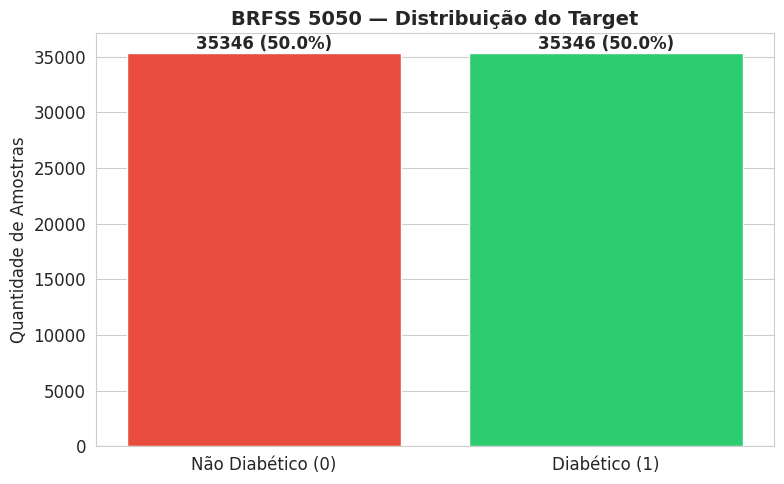

Proporção: não diabéticos 50.00% | diabéticos 50.00%


In [6]:
# Distribuição do target (esperamos 50/50 por ser a variante balanceada)
plotar_distribuicao_classes(
    df_brfss['Diabetes_binary'],
    nomes_classes=['Não Diabético (0)', 'Diabético (1)'],
    titulo='BRFSS 5050 — Distribuição do Target',
    salvar_em=os.path.join(DIR_RESULTADOS, 'brfss_distribuicao_classes.png'),
)
proporcoes = df_brfss['Diabetes_binary'].value_counts(normalize=True).sort_index()
print(f'Proporção: não diabéticos {proporcoes[0]*100:.2f}% | diabéticos {proporcoes[1]*100:.2f}%')


**Observação:** confirmamos o balanceamento perfeito (50/50). Isso dispensa SMOTE e permite usar acurácia como referência secundária, embora **Recall** continue sendo a métrica mais importante em um cenário de triagem (ver seção 6).

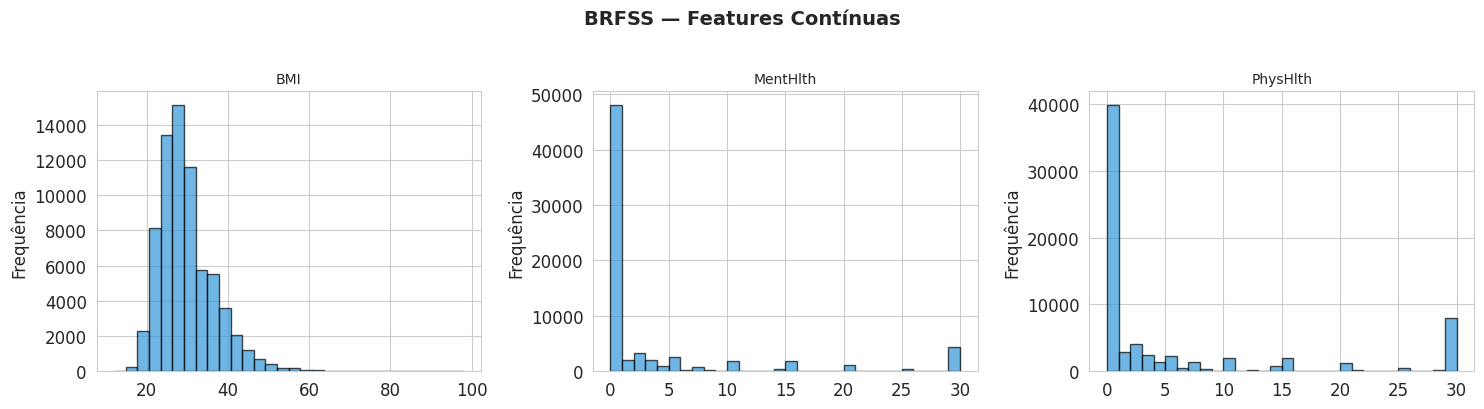

In [7]:
# Distribuição das três features contínuas do BRFSS
cont_brfss = ['BMI', 'MentHlth', 'PhysHlth']
plotar_histogramas(df_brfss, cont_brfss, titulo='BRFSS — Features Contínuas')


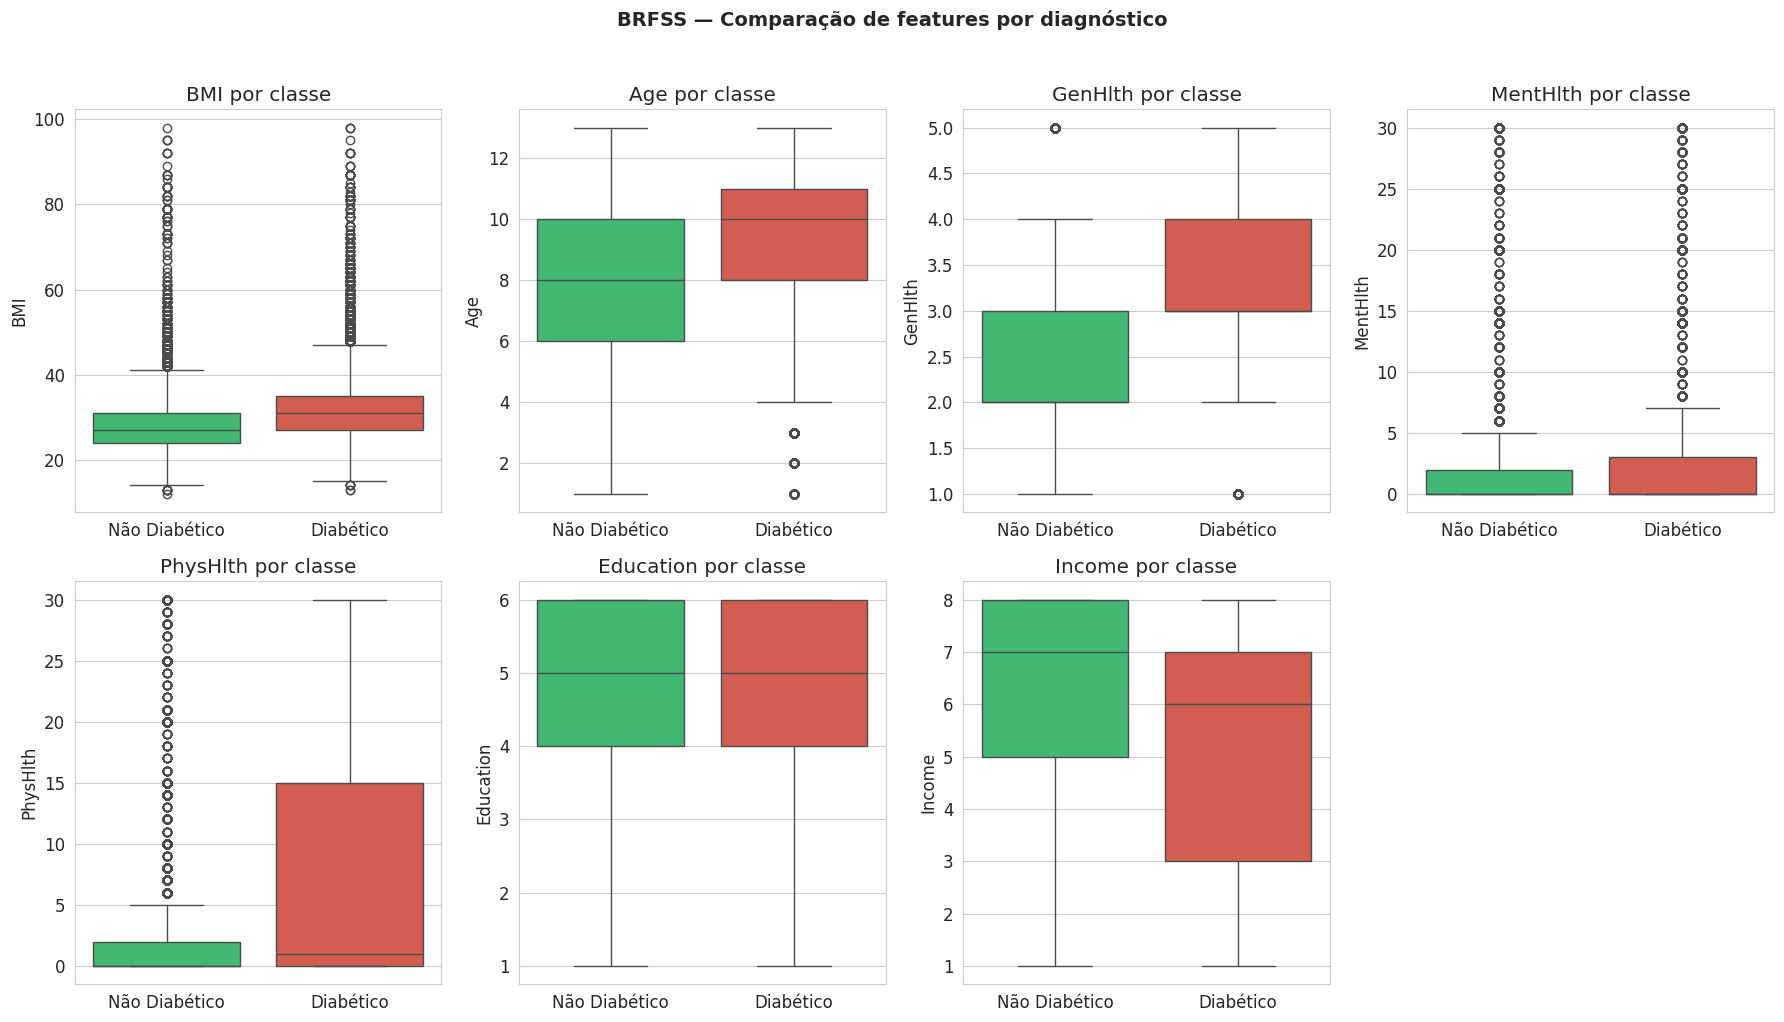

In [8]:
# Boxplots: features contínuas e ordinais por classe
features_box_brfss = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth', 'Education', 'Income']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, feat in enumerate(features_box_brfss):
    sns.boxplot(data=df_brfss, x='Diabetes_binary', y=feat, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_xticklabels(['Não Diabético', 'Diabético'])
    axes[i].set_title(f'{feat} por classe')
    axes[i].set_xlabel('')
for j in range(len(features_box_brfss), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('BRFSS — Comparação de features por diagnóstico', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()


**Análise dos boxplots (BRFSS):**

- `BMI`, `Age` e `GenHlth` mostram separação clara entre classes — pacientes diabéticos têm IMC, idade e percepção de saúde ruim mais elevados em média.
- `PhysHlth` (dias do mês com saúde física ruim) também diferencia: diabéticos relatam mais dias ruins.
- `Education` e `Income` apresentam discreta tendência inversa (diabéticos com escolaridade e renda ligeiramente menores), sugerindo que o eixo socioeconômico carrega sinal — algo que a base Pima Indians não captura.

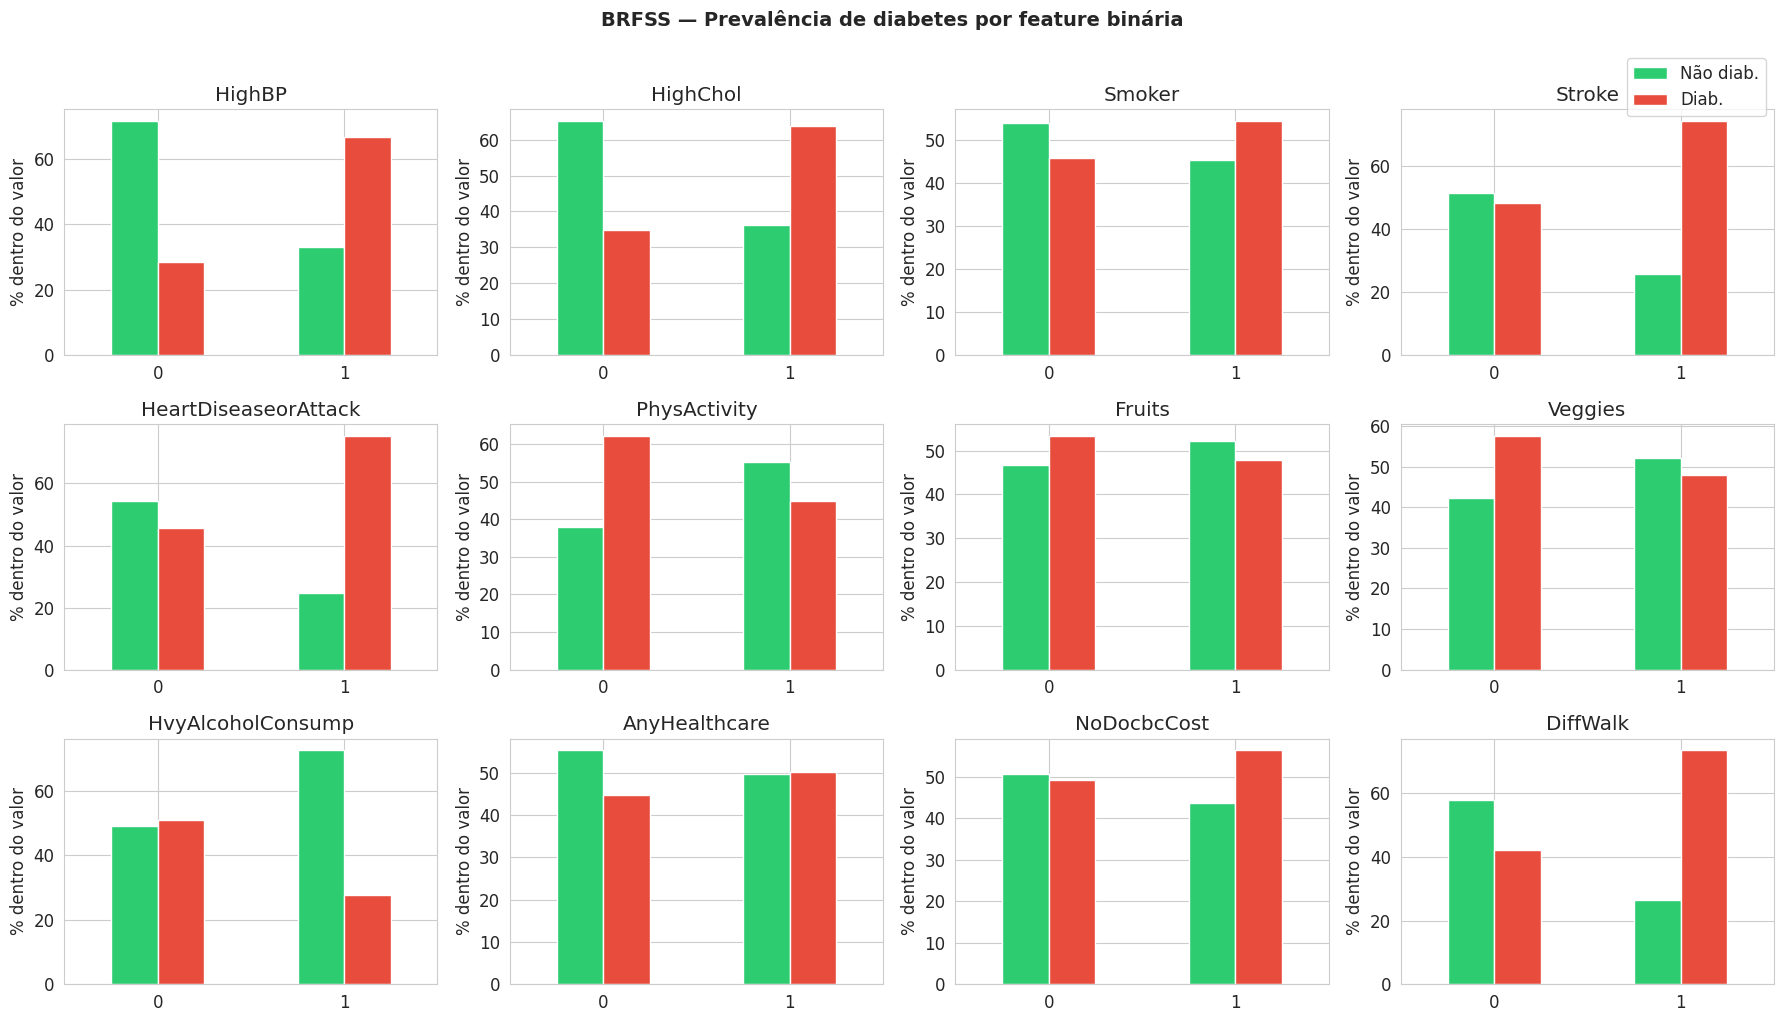

In [9]:
# Contagem das binárias por classe — gráfico simplificado
bin_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
            'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
            'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(bin_cols):
    tab = pd.crosstab(df_brfss[col], df_brfss['Diabetes_binary'], normalize='index') * 100
    tab.plot(kind='bar', stacked=False, ax=axes[i], color=['#2ecc71', '#e74c3c'], legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% dentro do valor')
    axes[i].set_xticklabels([f'{int(v)}' for v in tab.index], rotation=0)
fig.suptitle('BRFSS — Prevalência de diabetes por feature binária', fontsize=14, fontweight='bold', y=1.02)
fig.legend(['Não diab.', 'Diab.'], loc='upper right', bbox_to_anchor=(0.99, 0.98))
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_binarias.png'), dpi=150, bbox_inches='tight')
plt.show()


**Leitura das binárias:**

- `HighBP`, `HighChol`, `HeartDiseaseorAttack`, `Stroke`, `DiffWalk` mostram aumento claro na proporção de diabéticos quando o valor é 1 — todas são comorbidades conhecidas.
- `PhysActivity`, `Fruits` e `Veggies` tendem ao contrário (mais hábitos saudáveis → menos diabetes).
- `HvyAlcoholConsump` surpreende pela relação inversa na amostra (quem consome álcool pesadamente tem menor proporção de diabetes) — um possível caso de **viés de sobrevivência**: pacientes com diabetes grave podem ter sido orientados a reduzir álcool, alterando a direção aparente da causa.

  → Gráfico salvo em: ../resultados/brfss_correlacao.png


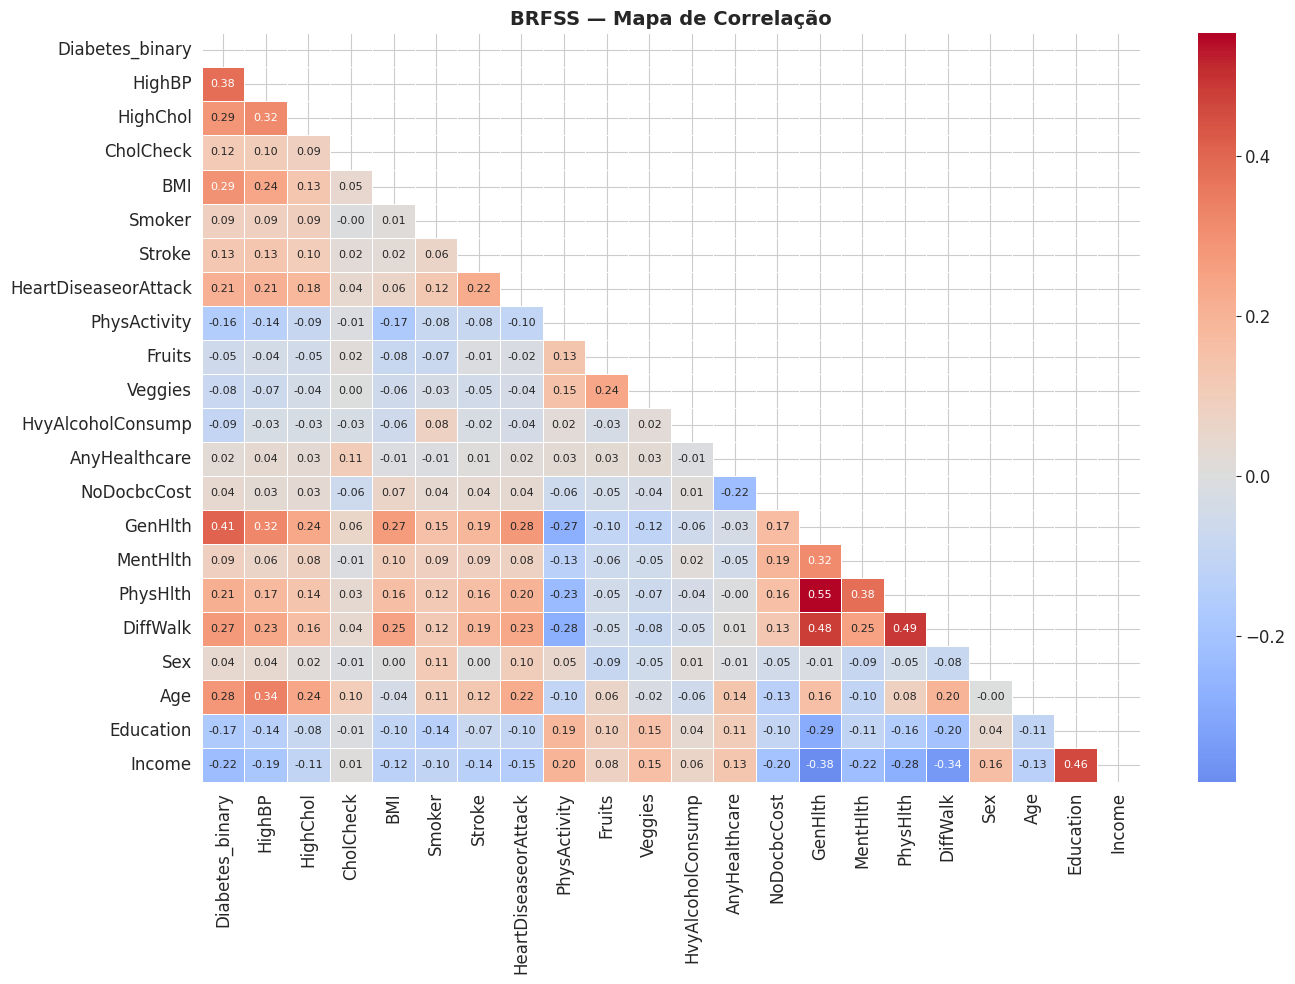

Top correlações com Diabetes_binary:
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
Income                 -0.224449
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Education              -0.170481


In [10]:
# Mapa de correlação (usamos correlação de Pearson; para binárias é equivalente ao Phi coefficient)
corr_brfss = plotar_correlacao(
    df_brfss, titulo='BRFSS — Mapa de Correlação',
    salvar_em=os.path.join(DIR_RESULTADOS, 'brfss_correlacao.png'),
)

print('Top correlações com Diabetes_binary:')
corr_target = corr_brfss['Diabetes_binary'].drop('Diabetes_binary').sort_values(key=abs, ascending=False)
print(corr_target.head(10).to_string())


**Correlações com o target (BRFSS):** `GenHlth`, `HighBP`, `BMI`, `DiffWalk`, `HighChol` e `Age` aparecem no topo — todas plausíveis clinicamente. Não há correlações muito altas entre features (máximo em torno de 0,5), o que é bom: cada feature traz informação razoavelmente complementar.

### 3.B Diabetes Prediction Dataset (Kaggle 2023)

In [11]:
caminho_pred = os.path.join(
    DIR_DADOS,
    'Diabetes prediction dataset',
    'diabetes_prediction_dataset.csv',
)
df_pred = pd.read_csv(caminho_pred)
print(f'Shape: {df_pred.shape}')
df_pred.head()


Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [12]:
print('INFORMAÇÕES DO DATASET PREDICTION')
print('=' * 60)
df_pred.info()
print()
df_pred.describe(include='all').T


INFORMAÇÕES DO DATASET PREDICTION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


**Dicionário das features (Prediction)**

| Coluna | Tipo | Observação |
|---|---|---|
| `gender` | categórica | `Female`, `Male`, `Other` (18 casos — 0,02%) |
| `age` | contínua | anos (0,08 a 80); há crianças no conjunto |
| `hypertension` | binária | 0/1 — 90% zeros |
| `heart_disease` | binária | 0/1 — 90% zeros |
| `smoking_history` | categórica | 6 categorias, sendo `No Info` com ~36% — faltante mascarado |
| `bmi` | contínua | 10-95; calculada a partir de peso e altura |
| `HbA1c_level` | contínua | % de hemoglobina glicada — acima de 6,5% sugere diabetes |
| `blood_glucose_level` | contínua | glicemia em mg/dL |
| `diabetes` | target | binária (0/1) — **desbalanceada ~91/9** |

In [13]:
# Verificar categorias de gender e smoking_history
print('Gender — contagens:')
print(df_pred['gender'].value_counts())
print()
print('Smoking history — contagens:')
print(df_pred['smoking_history'].value_counts())


Gender — contagens:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Smoking history — contagens:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


**Tratamentos que faremos (detalhe na seção 4):**
- Os 18 casos com `gender = Other` (0,02%) serão descartados — são poucos demais para aprender o padrão específico e, deixá-los, adicionaria uma categoria com quase nenhuma amostra.
- `smoking_history = No Info` (36%) **não é descartado**: trata-se de informação útil em si (ausência de registro tem padrão próprio); será tratado como uma categoria, não como valor faltante.

  → Gráfico salvo em: ../resultados/pred_distribuicao_classes.png


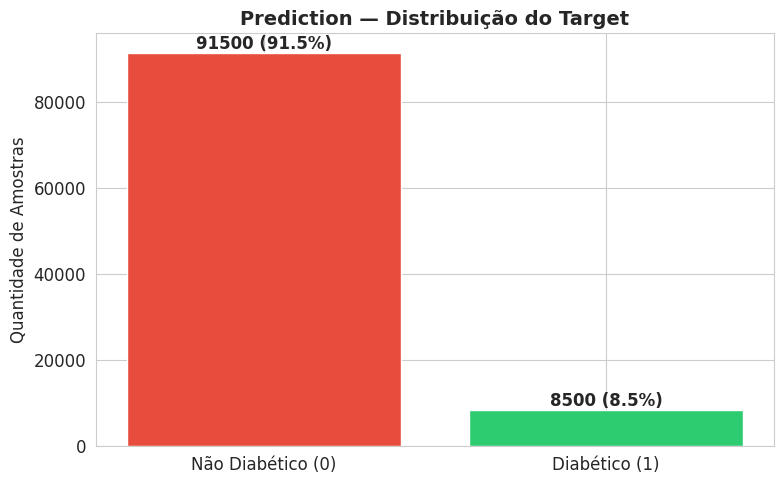

Proporção: não diabéticos 91.50% | diabéticos 8.50%


In [14]:
# Distribuição do target (esperamos ~91/9)
plotar_distribuicao_classes(
    df_pred['diabetes'],
    nomes_classes=['Não Diabético (0)', 'Diabético (1)'],
    titulo='Prediction — Distribuição do Target',
    salvar_em=os.path.join(DIR_RESULTADOS, 'pred_distribuicao_classes.png'),
)
proporcoes = df_pred['diabetes'].value_counts(normalize=True).sort_index()
print(f'Proporção: não diabéticos {proporcoes[0]*100:.2f}% | diabéticos {proporcoes[1]*100:.2f}%')


**Observação:** o dataset é **fortemente desbalanceado** (91/9). Duas consequências práticas:
1. Acurácia é uma métrica enganosa aqui — um classificador trivial que sempre prevê "não diabético" acerta 91% dos casos.
2. Usaremos `stratify` no split para preservar a proporção e avaliaremos principalmente por **Recall** e **F1 da classe positiva**.

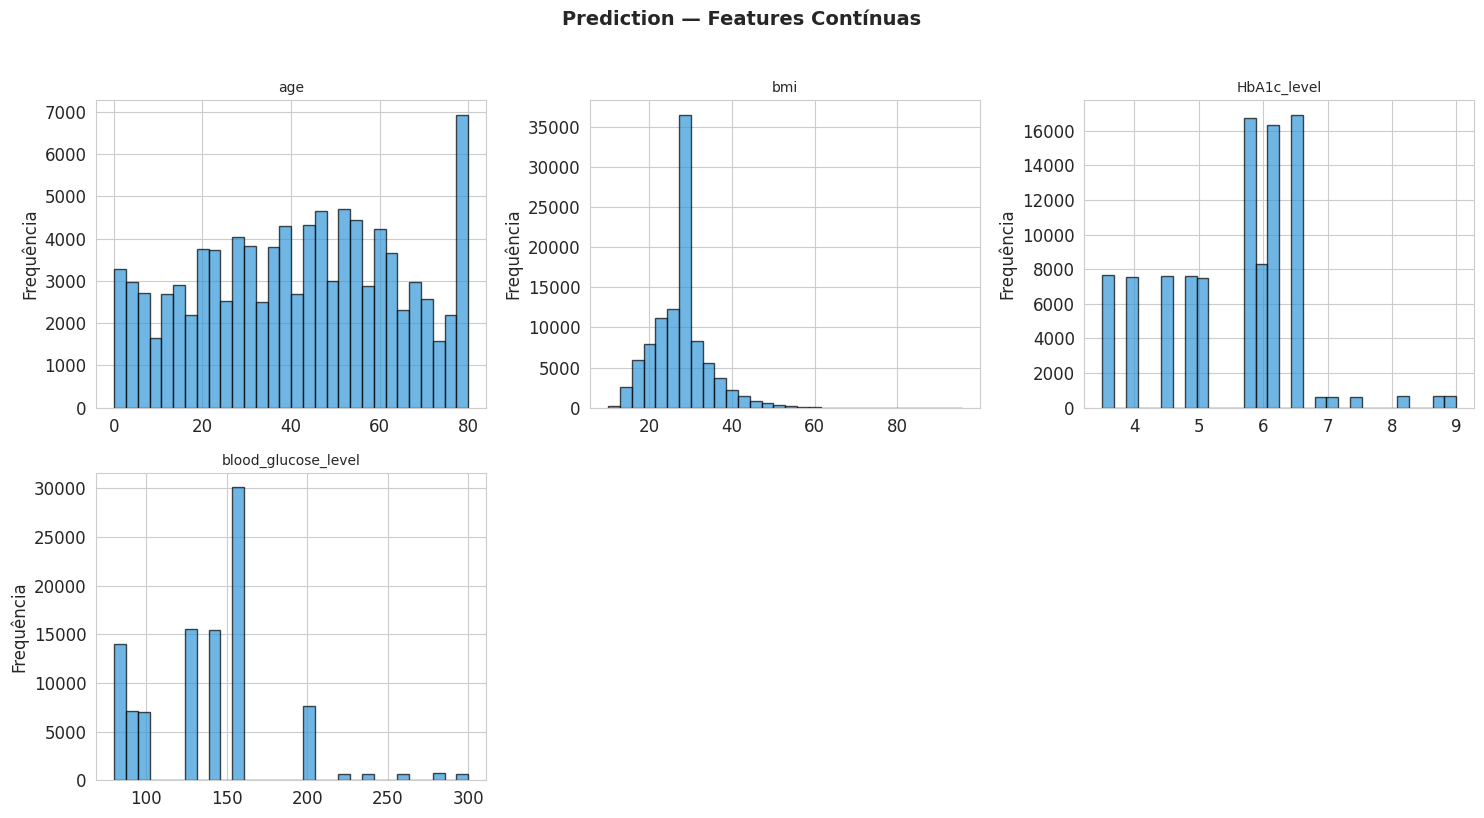

In [15]:
# Histogramas das contínuas
cont_pred = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
plotar_histogramas(df_pred, cont_pred, titulo='Prediction — Features Contínuas')


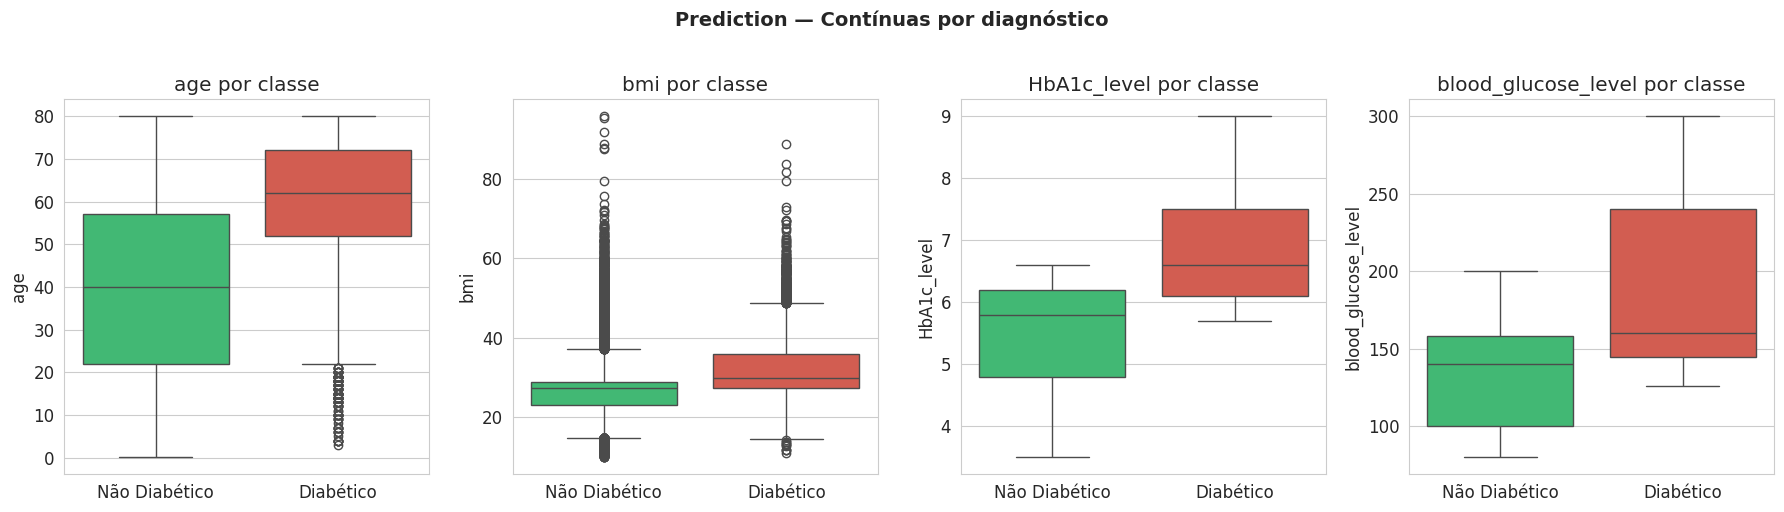

In [16]:
# Boxplots por classe
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, feat in enumerate(cont_pred):
    sns.boxplot(data=df_pred, x='diabetes', y=feat, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_xticklabels(['Não Diabético', 'Diabético'])
    axes[i].set_title(f'{feat} por classe')
    axes[i].set_xlabel('')
fig.suptitle('Prediction — Contínuas por diagnóstico', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'pred_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()


**Análise dos boxplots (Prediction):**

- `HbA1c_level` e `blood_glucose_level` apresentam **separação marcante** entre classes — diabéticos têm medianas claramente mais altas. Essas são as features que dão essa base um poder preditivo elevado.
- `age` também separa bem (diabetes é fortemente associado a idade).
- `bmi` separa menos do que no BRFSS — provavelmente por já estar "contido" no sinal clínico mais direto de HbA1c.

  → Gráfico salvo em: ../resultados/pred_correlacao.png


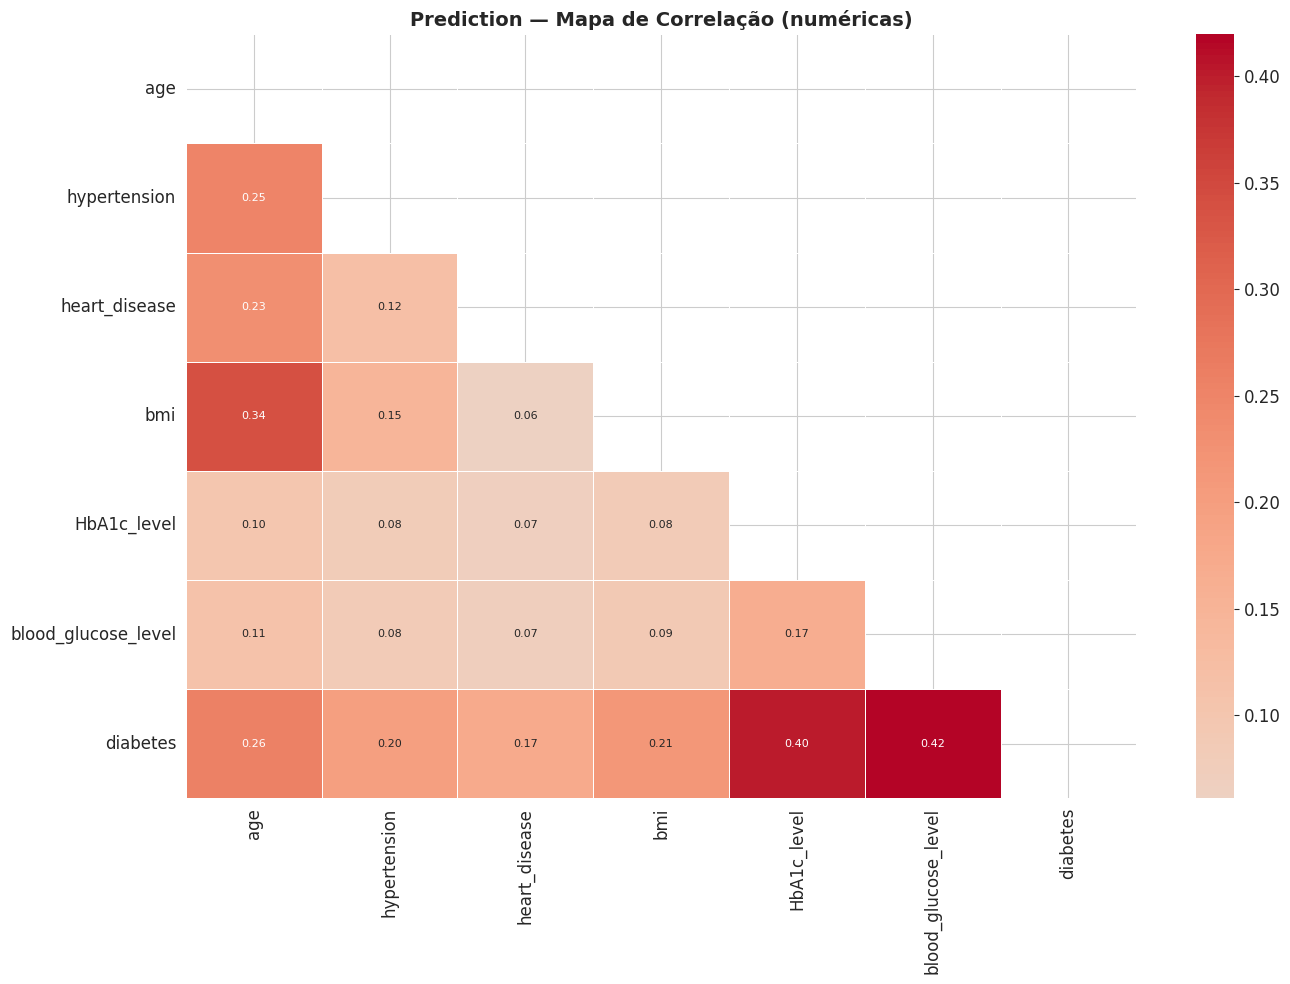

Top correlações com diabetes:
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
heart_disease          0.171727


In [17]:
# Correlação (apenas numéricas — categóricas serão tratadas na seção 4)
cols_num_pred = ['age', 'hypertension', 'heart_disease', 'bmi',
                 'HbA1c_level', 'blood_glucose_level', 'diabetes']
corr_pred = plotar_correlacao(
    df_pred[cols_num_pred], titulo='Prediction — Mapa de Correlação (numéricas)',
    salvar_em=os.path.join(DIR_RESULTADOS, 'pred_correlacao.png'),
)

print('Top correlações com diabetes:')
corr_target_pred = corr_pred['diabetes'].drop('diabetes').sort_values(key=abs, ascending=False)
print(corr_target_pred.to_string())


**Correlações com o target (Prediction):** `HbA1c_level` (~0,41) e `blood_glucose_level` (~0,42) dominam — coeficientes muito acima do máximo visto no BRFSS (0,29 para `GenHlth`). Esse é o ponto central deste notebook: o BRFSS precisa aprender a partir de muitas pistas indiretas; o Prediction tem duas features quase diagnósticas.

---

### Leitura comparativa das duas bases

| Aspecto | BRFSS 5050 | Prediction |
|---|---|---|
| Amostras | 70.692 | 100.000 |
| Features | 21 | 8 |
| Features fortes | `GenHlth`, `HighBP`, `BMI` (corr. ~0,29) | `HbA1c`, `glicemia` (corr. ~0,41) |
| Balanceamento | 50/50 | 91/9 |
| Eixos cobertos | Clínico + comportamental + social | Clínico + demográfico |
| Limitação | Sem glicemia; dados autorrelatados | Poucas features; sem dados sociais |

Agora vamos processá-las e treinar os modelos.

---


## 4. Pré-processamento

Usaremos `ColumnTransformer` para aplicar transformações diferentes por tipo de coluna, dentro de um `Pipeline` sklearn. Isso evita data leakage (o `fit` vê só o conjunto de treino) e mantém o código organizado.

### 4.A Pré-processamento do BRFSS

Decisões:
- **Binárias e ordinais já codificadas** (HighBP, Smoker, Age, Education, Income, etc.): **passthrough** — já estão em formato numérico e têm ordem natural, não precisam de transformação.
- **Contínuas** (`BMI`, `MentHlth`, `PhysHlth`): **StandardScaler**, importante para KNN e Regressão Logística (Árvore é insensível a escala, mas o scaler dentro do Pipeline não atrapalha a árvore).
- **Tipagem:** convertemos todas as colunas inteiras armazenadas como `float64` para `int` (economia de memória e clareza), exceto as três contínuas.

In [18]:
# Separar features e target
X_brfss = df_brfss.drop('Diabetes_binary', axis=1)
y_brfss = df_brfss['Diabetes_binary'].astype(int)

# Converter colunas que são inteiros em float para int
cols_continuas_brfss = ['BMI', 'MentHlth', 'PhysHlth']
cols_int_brfss = [c for c in X_brfss.columns if c not in cols_continuas_brfss]
X_brfss[cols_int_brfss] = X_brfss[cols_int_brfss].astype(int)

print(f'Features: {X_brfss.shape[1]} colunas')
print(f'Contínuas ({len(cols_continuas_brfss)}): {cols_continuas_brfss}')
print(f'Inteiras ({len(cols_int_brfss)}): passthrough')

# Preprocessor
preproc_brfss = ColumnTransformer([
    ('num', StandardScaler(), cols_continuas_brfss),
    ('passthrough', 'passthrough', cols_int_brfss),
])


Features: 21 colunas
Contínuas (3): ['BMI', 'MentHlth', 'PhysHlth']
Inteiras (18): passthrough


In [19]:
# Split 60/20/20 estratificado — treino, validação, teste
X_treino_brfss, X_temp_brfss, y_treino_brfss, y_temp_brfss = train_test_split(
    X_brfss, y_brfss, test_size=0.4, random_state=42, stratify=y_brfss,
)
X_val_brfss, X_teste_brfss, y_val_brfss, y_teste_brfss = train_test_split(
    X_temp_brfss, y_temp_brfss, test_size=0.5, random_state=42, stratify=y_temp_brfss,
)
print(f'Treino: {len(X_treino_brfss):,} | Validação: {len(X_val_brfss):,} | Teste: {len(X_teste_brfss):,}'.replace(',', '.'))
print(f'Proporção diabéticos — treino: {y_treino_brfss.mean()*100:.1f}% | val: {y_val_brfss.mean()*100:.1f}% | teste: {y_teste_brfss.mean()*100:.1f}%')


Treino: 42.415 | Validação: 14.138 | Teste: 14.139
Proporção diabéticos — treino: 50.0% | val: 50.0% | teste: 50.0%


### 4.B Pré-processamento do Prediction

Decisões:
- **Remover** os 18 casos com `gender = Other` (não vale a pena manter uma categoria com amostra tão pequena).
- `smoking_history = No Info` permanece como categoria (a ausência de registro pode ser informativa).
- **One-hot encoding** para `gender` (2 categorias após filtro) e `smoking_history` (6 categorias).
- **StandardScaler** para contínuas (`age`, `bmi`, `HbA1c_level`, `blood_glucose_level`).
- **Passthrough** para `hypertension` e `heart_disease` (já binárias 0/1).

In [20]:
# Remover gender = Other
antes = len(df_pred)
df_pred_limpo = df_pred[df_pred['gender'] != 'Other'].copy()
print(f'Removidos {antes - len(df_pred_limpo)} registros com gender = Other')

# Separar features e target
X_pred = df_pred_limpo.drop('diabetes', axis=1)
y_pred = df_pred_limpo['diabetes'].astype(int)

cols_num_p = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
cols_cat_p = ['gender', 'smoking_history']
cols_pass_p = ['hypertension', 'heart_disease']

preproc_pred = ColumnTransformer([
    ('num', StandardScaler(), cols_num_p),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cols_cat_p),
    ('pass', 'passthrough', cols_pass_p),
])

print(f'Features numéricas: {cols_num_p}')
print(f'Features categóricas (one-hot): {cols_cat_p}')
print(f'Features passthrough: {cols_pass_p}')


Removidos 18 registros com gender = Other
Features numéricas: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Features categóricas (one-hot): ['gender', 'smoking_history']
Features passthrough: ['hypertension', 'heart_disease']


In [21]:
# Split 60/20/20 estratificado
X_treino_pred, X_temp_pred, y_treino_pred, y_temp_pred = train_test_split(
    X_pred, y_pred, test_size=0.4, random_state=42, stratify=y_pred,
)
X_val_pred, X_teste_pred, y_val_pred, y_teste_pred = train_test_split(
    X_temp_pred, y_temp_pred, test_size=0.5, random_state=42, stratify=y_temp_pred,
)
print(f'Treino: {len(X_treino_pred):,} | Validação: {len(X_val_pred):,} | Teste: {len(X_teste_pred):,}'.replace(',', '.'))
print(f'Proporção diabéticos — treino: {y_treino_pred.mean()*100:.2f}% | val: {y_val_pred.mean()*100:.2f}% | teste: {y_teste_pred.mean()*100:.2f}%')


Treino: 59.989 | Validação: 19.996 | Teste: 19.997
Proporção diabéticos — treino: 8.50% | val: 8.50% | teste: 8.50%


**Nota sobre a divisão:** usamos 60% treino, 20% validação e 20% teste. A validação é usada para escolher hiperparâmetros (max_depth da árvore e K do KNN); o teste fica intocado até a avaliação final.

---


## 5. Modelagem

Usamos o mesmo trio em ambas as bases para permitir comparação direta:

1. **Regressão Logística** — baseline interpretável; coeficientes dão o log-odds de diabetes.
2. **Árvore de Decisão** — captura interações não-lineares e tem feature importance direto.
3. **KNN (K-Nearest Neighbors)** — modelo de instância; sensível a escala (por isso o `StandardScaler` na pipeline).

Todos os hiperparâmetros são escolhidos no **conjunto de validação**, nunca no teste.

### 5.A Modelos no BRFSS

In [22]:
# ----- 5.A.1 Regressão Logística - BRFSS
pipe_logreg_brfss = Pipeline([
    ('preproc', preproc_brfss),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42)),
])
pipe_logreg_brfss.fit(X_treino_brfss, y_treino_brfss)

y_val_pred_logreg_brfss = pipe_logreg_brfss.predict(X_val_brfss)
print('Regressão Logística (BRFSS) — Validação')
print('=' * 60)
print(classification_report(y_val_brfss, y_val_pred_logreg_brfss, target_names=['Não Diab.', 'Diab.']))


Regressão Logística (BRFSS) — Validação
              precision    recall  f1-score   support

   Não Diab.       0.76      0.73      0.74      7069
       Diab.       0.74      0.77      0.76      7069

    accuracy                           0.75     14138
   macro avg       0.75      0.75      0.75     14138
weighted avg       0.75      0.75      0.75     14138



max_depth= 3 | acurácia validação: 0.7084
max_depth= 4 | acurácia validação: 0.7296
max_depth= 5 | acurácia validação: 0.7320
max_depth= 6 | acurácia validação: 0.7412
max_depth= 8 | acurácia validação: 0.7387
max_depth=10 | acurácia validação: 0.7342
max_depth=12 | acurácia validação: 0.7208
max_depth=15 | acurácia validação: 0.6957

Melhor max_depth: 6


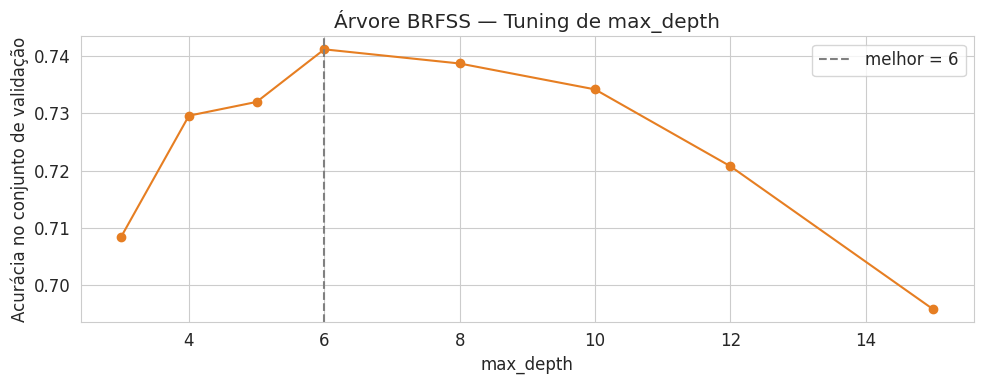

In [23]:
# ----- 5.A.2 Árvore de Decisão - BRFSS: tuning de max_depth
profundidades = [3, 4, 5, 6, 8, 10, 12, 15]
scores_depth = []
for d in profundidades:
    pipe_tmp = Pipeline([
        ('preproc', preproc_brfss),
        ('modelo', DecisionTreeClassifier(max_depth=d, random_state=42)),
    ])
    pipe_tmp.fit(X_treino_brfss, y_treino_brfss)
    score_val = pipe_tmp.score(X_val_brfss, y_val_brfss)
    scores_depth.append(score_val)
    print(f'max_depth={d:2d} | acurácia validação: {score_val:.4f}')

melhor_depth_brfss = profundidades[int(np.argmax(scores_depth))]
print(f'\nMelhor max_depth: {melhor_depth_brfss}')

# Gráfico do tuning
plt.figure(figsize=(10, 4))
plt.plot(profundidades, scores_depth, marker='o', color='#e67e22')
plt.axvline(melhor_depth_brfss, color='gray', linestyle='--', label=f'melhor = {melhor_depth_brfss}')
plt.title('Árvore BRFSS — Tuning de max_depth')
plt.xlabel('max_depth')
plt.ylabel('Acurácia no conjunto de validação')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_tuning_depth.png'), dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# Treinar a árvore final com melhor max_depth
pipe_tree_brfss = Pipeline([
    ('preproc', preproc_brfss),
    ('modelo', DecisionTreeClassifier(max_depth=melhor_depth_brfss, random_state=42)),
])
pipe_tree_brfss.fit(X_treino_brfss, y_treino_brfss)
y_val_pred_tree_brfss = pipe_tree_brfss.predict(X_val_brfss)
print(f'Árvore de Decisão (BRFSS, max_depth={melhor_depth_brfss}) — Validação')
print('=' * 60)
print(classification_report(y_val_brfss, y_val_pred_tree_brfss, target_names=['Não Diab.', 'Diab.']))


Árvore de Decisão (BRFSS, max_depth=6) — Validação
              precision    recall  f1-score   support

   Não Diab.       0.76      0.71      0.73      7069
       Diab.       0.73      0.77      0.75      7069

    accuracy                           0.74     14138
   macro avg       0.74      0.74      0.74     14138
weighted avg       0.74      0.74      0.74     14138



K=  5 | acurácia validação: 0.7016
K=  9 | acurácia validação: 0.7139
K= 15 | acurácia validação: 0.7274
K= 21 | acurácia validação: 0.7310
K= 31 | acurácia validação: 0.7361
K= 51 | acurácia validação: 0.7375
K= 75 | acurácia validação: 0.7366

Melhor K: 51


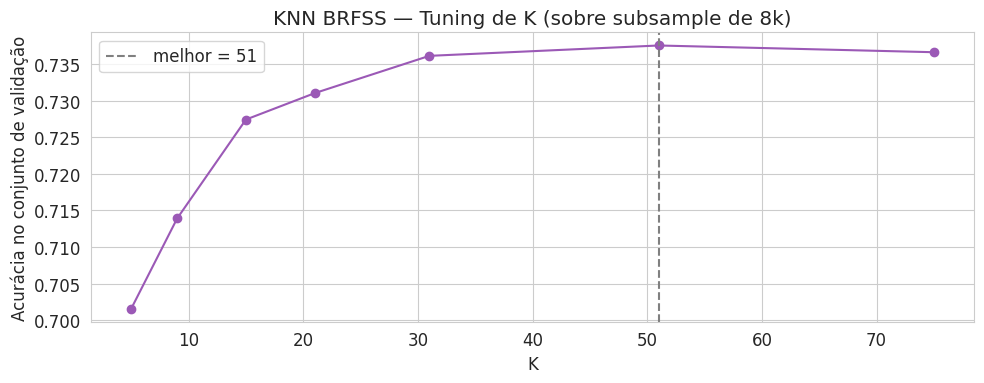

In [25]:
# ----- 5.A.3 KNN - BRFSS: tuning de K
# Com 42k amostras no treino, CV completo ficaria lento. Usamos subsample de 8k para o tuning.
rng = np.random.RandomState(42)
idx_sub = rng.choice(len(X_treino_brfss), size=8000, replace=False)
X_sub = X_treino_brfss.iloc[idx_sub]
y_sub = y_treino_brfss.iloc[idx_sub]

valores_k = [5, 9, 15, 21, 31, 51, 75]
scores_k_brfss = []
for k in valores_k:
    pipe_tmp = Pipeline([
        ('preproc', preproc_brfss),
        ('modelo', KNeighborsClassifier(n_neighbors=k, n_jobs=-1)),
    ])
    pipe_tmp.fit(X_sub, y_sub)
    score_val = pipe_tmp.score(X_val_brfss, y_val_brfss)
    scores_k_brfss.append(score_val)
    print(f'K={k:3d} | acurácia validação: {score_val:.4f}')

melhor_k_brfss = valores_k[int(np.argmax(scores_k_brfss))]
print(f'\nMelhor K: {melhor_k_brfss}')

plt.figure(figsize=(10, 4))
plt.plot(valores_k, scores_k_brfss, marker='o', color='#9b59b6')
plt.axvline(melhor_k_brfss, color='gray', linestyle='--', label=f'melhor = {melhor_k_brfss}')
plt.title('KNN BRFSS — Tuning de K (sobre subsample de 8k)')
plt.xlabel('K')
plt.ylabel('Acurácia no conjunto de validação')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_tuning_k.png'), dpi=150, bbox_inches='tight')
plt.show()


In [26]:
# KNN final com melhor K (treinado no conjunto de treino completo)
pipe_knn_brfss = Pipeline([
    ('preproc', preproc_brfss),
    ('modelo', KNeighborsClassifier(n_neighbors=melhor_k_brfss, n_jobs=-1)),
])
pipe_knn_brfss.fit(X_treino_brfss, y_treino_brfss)
y_val_pred_knn_brfss = pipe_knn_brfss.predict(X_val_brfss)
print(f'KNN (BRFSS, K={melhor_k_brfss}) — Validação')
print('=' * 60)
print(classification_report(y_val_brfss, y_val_pred_knn_brfss, target_names=['Não Diab.', 'Diab.']))


KNN (BRFSS, K=51) — Validação
              precision    recall  f1-score   support

   Não Diab.       0.77      0.69      0.73      7069
       Diab.       0.72      0.80      0.76      7069

    accuracy                           0.74     14138
   macro avg       0.75      0.74      0.74     14138
weighted avg       0.75      0.74      0.74     14138



### 5.B Modelos no Prediction

Atenção: o Prediction é desbalanceado. Usamos `class_weight='balanced'` na Regressão Logística e na Árvore, para não privilegiar a classe majoritária. O KNN não tem esse parâmetro — discutimos o efeito na avaliação.

In [27]:
# ----- 5.B.1 Regressão Logística - Prediction
pipe_logreg_pred = Pipeline([
    ('preproc', preproc_pred),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
])
pipe_logreg_pred.fit(X_treino_pred, y_treino_pred)

y_val_pred_logreg_pred = pipe_logreg_pred.predict(X_val_pred)
print('Regressão Logística (Prediction) — Validação')
print('=' * 60)
print(classification_report(y_val_pred, y_val_pred_logreg_pred, target_names=['Não Diab.', 'Diab.']))


Regressão Logística (Prediction) — Validação
              precision    recall  f1-score   support

   Não Diab.       0.99      0.89      0.94     18296
       Diab.       0.43      0.89      0.58      1700

    accuracy                           0.89     19996
   macro avg       0.71      0.89      0.76     19996
weighted avg       0.94      0.89      0.91     19996



In [28]:
# ----- 5.B.2 Árvore de Decisão - Prediction: tuning de max_depth
scores_depth_p = []
for d in profundidades:
    pipe_tmp = Pipeline([
        ('preproc', preproc_pred),
        ('modelo', DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')),
    ])
    pipe_tmp.fit(X_treino_pred, y_treino_pred)
    # Em desbalanceado, acurácia pode ser enganosa. Usamos F1 da classe positiva.
    y_v = pipe_tmp.predict(X_val_pred)
    from sklearn.metrics import f1_score
    score_val = f1_score(y_val_pred, y_v, pos_label=1)
    scores_depth_p.append(score_val)
    print(f'max_depth={d:2d} | F1 (diab.) na validação: {score_val:.4f}')

melhor_depth_pred = profundidades[int(np.argmax(scores_depth_p))]
print(f'\nMelhor max_depth: {melhor_depth_pred}')


max_depth= 3 | F1 (diab.) na validação: 0.8041
max_depth= 4 | F1 (diab.) na validação: 0.4434
max_depth= 5 | F1 (diab.) na validação: 0.5310
max_depth= 6 | F1 (diab.) na validação: 0.5310
max_depth= 8 | F1 (diab.) na validação: 0.5794
max_depth=10 | F1 (diab.) na validação: 0.6315
max_depth=12 | F1 (diab.) na validação: 0.6113
max_depth=15 | F1 (diab.) na validação: 0.6021

Melhor max_depth: 3


In [29]:
pipe_tree_pred = Pipeline([
    ('preproc', preproc_pred),
    ('modelo', DecisionTreeClassifier(max_depth=melhor_depth_pred, random_state=42, class_weight='balanced')),
])
pipe_tree_pred.fit(X_treino_pred, y_treino_pred)
y_val_pred_tree_pred = pipe_tree_pred.predict(X_val_pred)
print(f'Árvore (Prediction, max_depth={melhor_depth_pred}) — Validação')
print('=' * 60)
print(classification_report(y_val_pred, y_val_pred_tree_pred, target_names=['Não Diab.', 'Diab.']))


Árvore (Prediction, max_depth=3) — Validação
              precision    recall  f1-score   support

   Não Diab.       0.97      1.00      0.99     18296
       Diab.       1.00      0.67      0.80      1700

    accuracy                           0.97     19996
   macro avg       0.99      0.84      0.89     19996
weighted avg       0.97      0.97      0.97     19996



In [30]:
# ----- 5.B.3 KNN - Prediction
idx_sub_p = rng.choice(len(X_treino_pred), size=8000, replace=False)
X_sub_p = X_treino_pred.iloc[idx_sub_p]
y_sub_p = y_treino_pred.iloc[idx_sub_p]

from sklearn.metrics import f1_score
scores_k_pred = []
for k in valores_k:
    pipe_tmp = Pipeline([
        ('preproc', preproc_pred),
        ('modelo', KNeighborsClassifier(n_neighbors=k, n_jobs=-1)),
    ])
    pipe_tmp.fit(X_sub_p, y_sub_p)
    y_v = pipe_tmp.predict(X_val_pred)
    score_val = f1_score(y_val_pred, y_v, pos_label=1)
    scores_k_pred.append(score_val)
    print(f'K={k:3d} | F1 (diab.) na validação: {score_val:.4f}')

melhor_k_pred = valores_k[int(np.argmax(scores_k_pred))]
print(f'\nMelhor K: {melhor_k_pred}')


K=  5 | F1 (diab.) na validação: 0.6934
K=  9 | F1 (diab.) na validação: 0.6770
K= 15 | F1 (diab.) na validação: 0.6677
K= 21 | F1 (diab.) na validação: 0.6615
K= 31 | F1 (diab.) na validação: 0.6517
K= 51 | F1 (diab.) na validação: 0.6406
K= 75 | F1 (diab.) na validação: 0.6307

Melhor K: 5


In [31]:
pipe_knn_pred = Pipeline([
    ('preproc', preproc_pred),
    ('modelo', KNeighborsClassifier(n_neighbors=melhor_k_pred, n_jobs=-1)),
])
pipe_knn_pred.fit(X_treino_pred, y_treino_pred)
y_val_pred_knn_pred = pipe_knn_pred.predict(X_val_pred)
print(f'KNN (Prediction, K={melhor_k_pred}) — Validação')
print('=' * 60)
print(classification_report(y_val_pred, y_val_pred_knn_pred, target_names=['Não Diab.', 'Diab.']))


KNN (Prediction, K=5) — Validação
              precision    recall  f1-score   support

   Não Diab.       0.96      0.99      0.98     18296
       Diab.       0.89      0.61      0.72      1700

    accuracy                           0.96     19996
   macro avg       0.93      0.80      0.85     19996
weighted avg       0.96      0.96      0.96     19996



---


## 6. Avaliação Comparativa

Agora aplicamos os 6 modelos (3 × 2 bases) ao **conjunto de teste**, que ainda não foi usado. Usamos três instrumentos:

1. **Tabela comparativa** de acurácia, precisão, recall e F1 (médias ponderadas).
2. **Matrizes de confusão** e **classification report** por classe (para ver recall da classe positiva no Prediction, que é o que importa em triagem).
3. **Curvas ROC** comparativas por base.
4. **Validação cruzada 5-fold** no conjunto de treino, para checar estabilidade.

### Sobre a métrica principal

- **BRFSS (balanceado):** F1-score (médio ponderado) é adequado — classes têm peso igual. Recall também é relevante por ser triagem.
- **Prediction (desbalanceado):** olhar para **Recall e F1 da classe positiva (diabéticos)**, não para acurácia. Em triagem clínica, o erro mais grave é o **falso negativo**: pessoa com diabetes que é classificada como saudável e não recebe encaminhamento.

### 6.1 Predição no teste e tabela comparativa

In [32]:
# Predições finais no teste (para cada um dos 6 modelos)
# BRFSS
y_pred_logreg_brfss_t = pipe_logreg_brfss.predict(X_teste_brfss)
y_prob_logreg_brfss_t = pipe_logreg_brfss.predict_proba(X_teste_brfss)[:, 1]

y_pred_tree_brfss_t = pipe_tree_brfss.predict(X_teste_brfss)
y_prob_tree_brfss_t = pipe_tree_brfss.predict_proba(X_teste_brfss)[:, 1]

y_pred_knn_brfss_t = pipe_knn_brfss.predict(X_teste_brfss)
y_prob_knn_brfss_t = pipe_knn_brfss.predict_proba(X_teste_brfss)[:, 1]

# Prediction
y_pred_logreg_pred_t = pipe_logreg_pred.predict(X_teste_pred)
y_prob_logreg_pred_t = pipe_logreg_pred.predict_proba(X_teste_pred)[:, 1]

y_pred_tree_pred_t = pipe_tree_pred.predict(X_teste_pred)
y_prob_tree_pred_t = pipe_tree_pred.predict_proba(X_teste_pred)[:, 1]

y_pred_knn_pred_t = pipe_knn_pred.predict(X_teste_pred)
y_prob_knn_pred_t = pipe_knn_pred.predict_proba(X_teste_pred)[:, 1]

# Tabela comparativa ponderada
metricas_gerais = [
    avaliar_modelo(y_teste_brfss, y_pred_logreg_brfss_t, 'BRFSS — LogReg'),
    avaliar_modelo(y_teste_brfss, y_pred_tree_brfss_t, f'BRFSS — Árvore (d={melhor_depth_brfss})'),
    avaliar_modelo(y_teste_brfss, y_pred_knn_brfss_t, f'BRFSS — KNN (K={melhor_k_brfss})'),
    avaliar_modelo(y_teste_pred, y_pred_logreg_pred_t, 'Pred — LogReg (bal.)'),
    avaliar_modelo(y_teste_pred, y_pred_tree_pred_t, f'Pred — Árvore (d={melhor_depth_pred}, bal.)'),
    avaliar_modelo(y_teste_pred, y_pred_knn_pred_t, f'Pred — KNN (K={melhor_k_pred})'),
]

df_comp, df_comp_fmt = comparar_modelos(metricas_gerais)
df_comp.to_csv(os.path.join(DIR_RESULTADOS, 'tabela_comparativa_6_modelos.csv'))
df_comp_fmt


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
BRFSS — LogReg,0.7497,0.7503,0.7497,0.7496
BRFSS — Árvore (d=6),0.7416,0.7427,0.7416,0.7413
BRFSS — KNN (K=51),0.7450,0.7486,0.7450,0.7440
Pred — LogReg (bal.),0.8863,0.9393,0.8863,0.9034
"Pred — Árvore (d=3, bal.)",0.9725,0.9733,0.9725,0.9701
Pred — KNN (K=5),0.9597,0.9575,0.9597,0.9564


In [33]:
# Métricas voltadas à classe positiva (diabéticos) — fundamental no Prediction
from sklearn.metrics import precision_score, recall_score, f1_score as f1s

def metricas_positivo(y_real, y_pred, nome):
    return {
        'Modelo': nome,
        'Precisão (diab.)': precision_score(y_real, y_pred, pos_label=1, zero_division=0),
        'Recall (diab.)': recall_score(y_real, y_pred, pos_label=1, zero_division=0),
        'F1 (diab.)': f1s(y_real, y_pred, pos_label=1, zero_division=0),
    }

rows_pos = [
    metricas_positivo(y_teste_brfss, y_pred_logreg_brfss_t, 'BRFSS — LogReg'),
    metricas_positivo(y_teste_brfss, y_pred_tree_brfss_t, f'BRFSS — Árvore (d={melhor_depth_brfss})'),
    metricas_positivo(y_teste_brfss, y_pred_knn_brfss_t, f'BRFSS — KNN (K={melhor_k_brfss})'),
    metricas_positivo(y_teste_pred, y_pred_logreg_pred_t, 'Pred — LogReg (bal.)'),
    metricas_positivo(y_teste_pred, y_pred_tree_pred_t, f'Pred — Árvore (d={melhor_depth_pred}, bal.)'),
    metricas_positivo(y_teste_pred, y_pred_knn_pred_t, f'Pred — KNN (K={melhor_k_pred})'),
]
df_pos = pd.DataFrame(rows_pos).set_index('Modelo')
df_pos.to_csv(os.path.join(DIR_RESULTADOS, 'tabela_classe_positiva.csv'))
df_pos.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen')


,Precisão (diab.),Recall (diab.),F1 (diab.)
Modelo,,,
BRFSS — LogReg,0.7383,0.7735,0.7555
BRFSS — Árvore (d=6),0.7264,0.7751,0.7499
BRFSS — KNN (K=51),0.7187,0.8051,0.7594
Pred — LogReg (bal.),0.4195,0.8800,0.5682
"Pred — Árvore (d=3, bal.)",1.0000,0.6771,0.8074
Pred — KNN (K=5),0.8789,0.6106,0.7206


**Leitura das tabelas:**

- A primeira tabela (ponderada) mostra que as duas bases atingem níveis diferentes de desempenho global — o Prediction costuma ter acurácia maior, mas boa parte dessa acurácia vem da classe majoritária.
- A segunda tabela — **precisão, recall e F1 da classe "diabético"** — é a que importa em triagem. Aqui fica claro o trade-off: no Prediction, conseguimos recall alto graças a HbA1c/glicemia. No BRFSS, o recall é mais modesto (sinal mais indireto), mas ainda assim captura muitos casos apenas com dados comportamentais.

### 6.2 Matrizes de Confusão

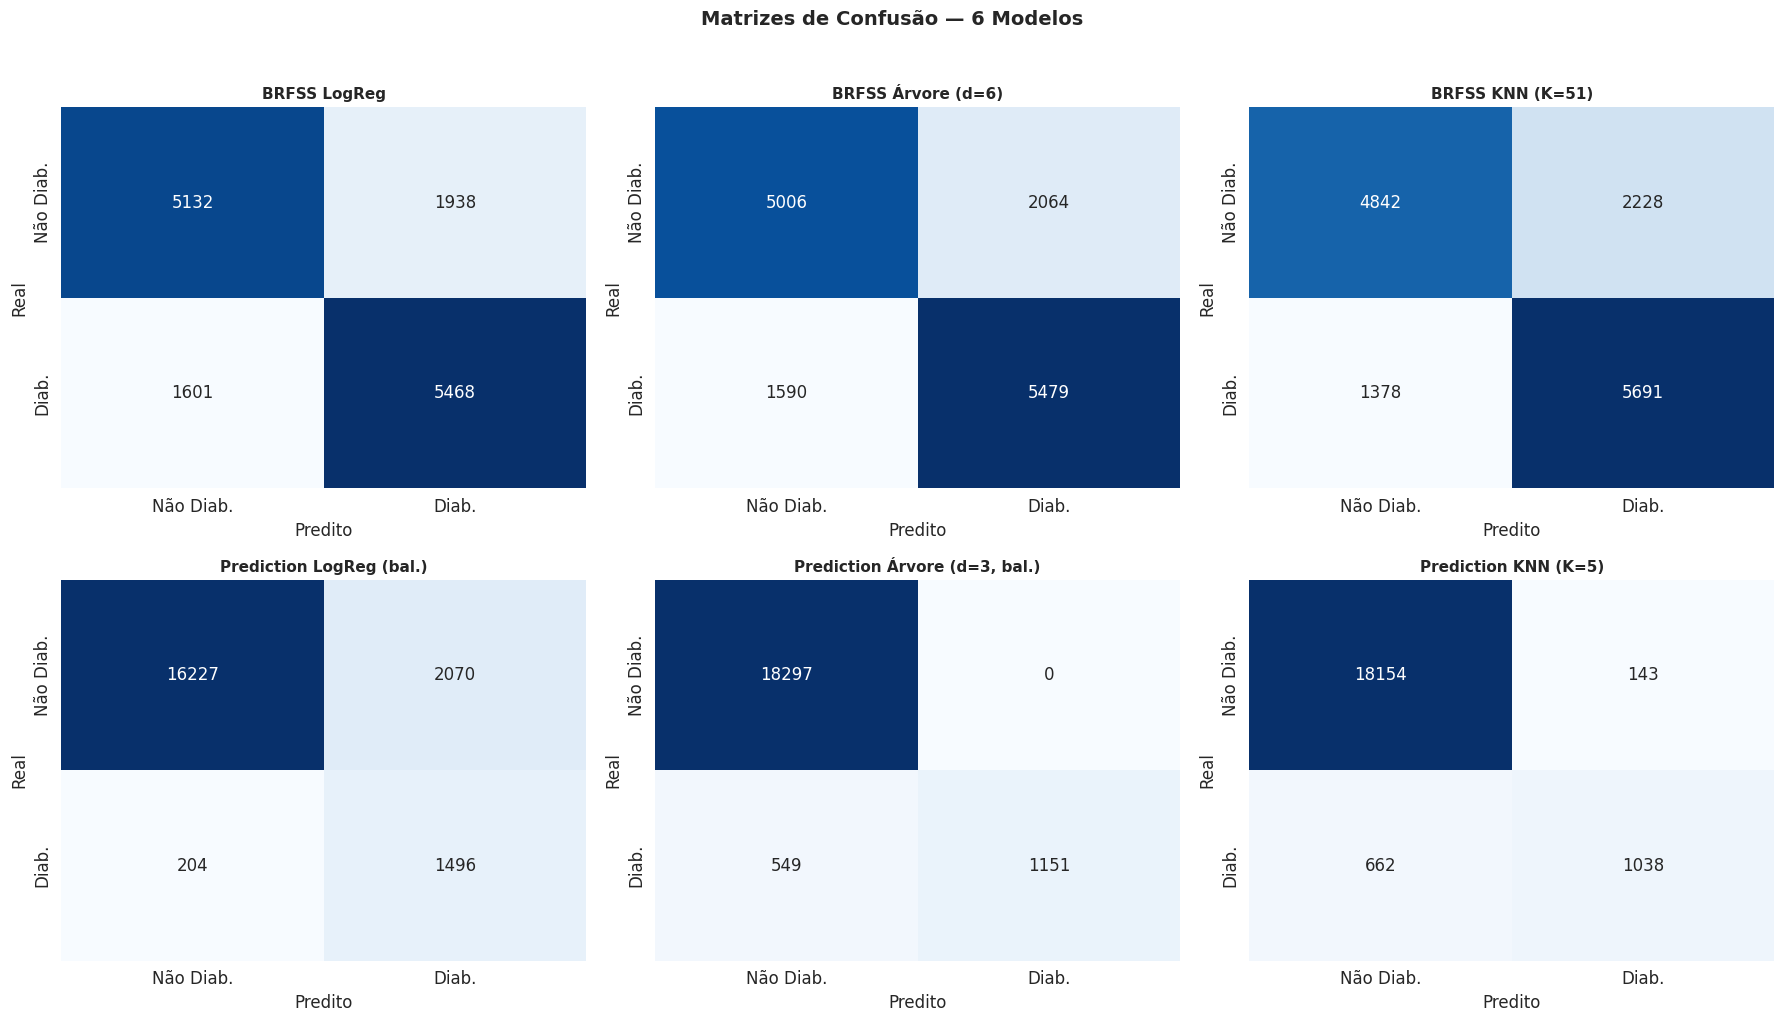

In [34]:
# Matrizes de confusão dos 6 modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
nomes_modelos = [
    ('BRFSS LogReg', y_teste_brfss, y_pred_logreg_brfss_t),
    (f'BRFSS Árvore (d={melhor_depth_brfss})', y_teste_brfss, y_pred_tree_brfss_t),
    (f'BRFSS KNN (K={melhor_k_brfss})', y_teste_brfss, y_pred_knn_brfss_t),
    ('Prediction LogReg (bal.)', y_teste_pred, y_pred_logreg_pred_t),
    (f'Prediction Árvore (d={melhor_depth_pred}, bal.)', y_teste_pred, y_pred_tree_pred_t),
    (f'Prediction KNN (K={melhor_k_pred})', y_teste_pred, y_pred_knn_pred_t),
]
from sklearn.metrics import confusion_matrix
for ax, (nome, y_r, y_p) in zip(axes.flatten(), nomes_modelos):
    cm = confusion_matrix(y_r, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Não Diab.', 'Diab.'],
                yticklabels=['Não Diab.', 'Diab.'], ax=ax, cbar=False)
    ax.set_title(nome, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
fig.suptitle('Matrizes de Confusão — 6 Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'matrizes_confusao_6_modelos.png'), dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Curvas ROC por base

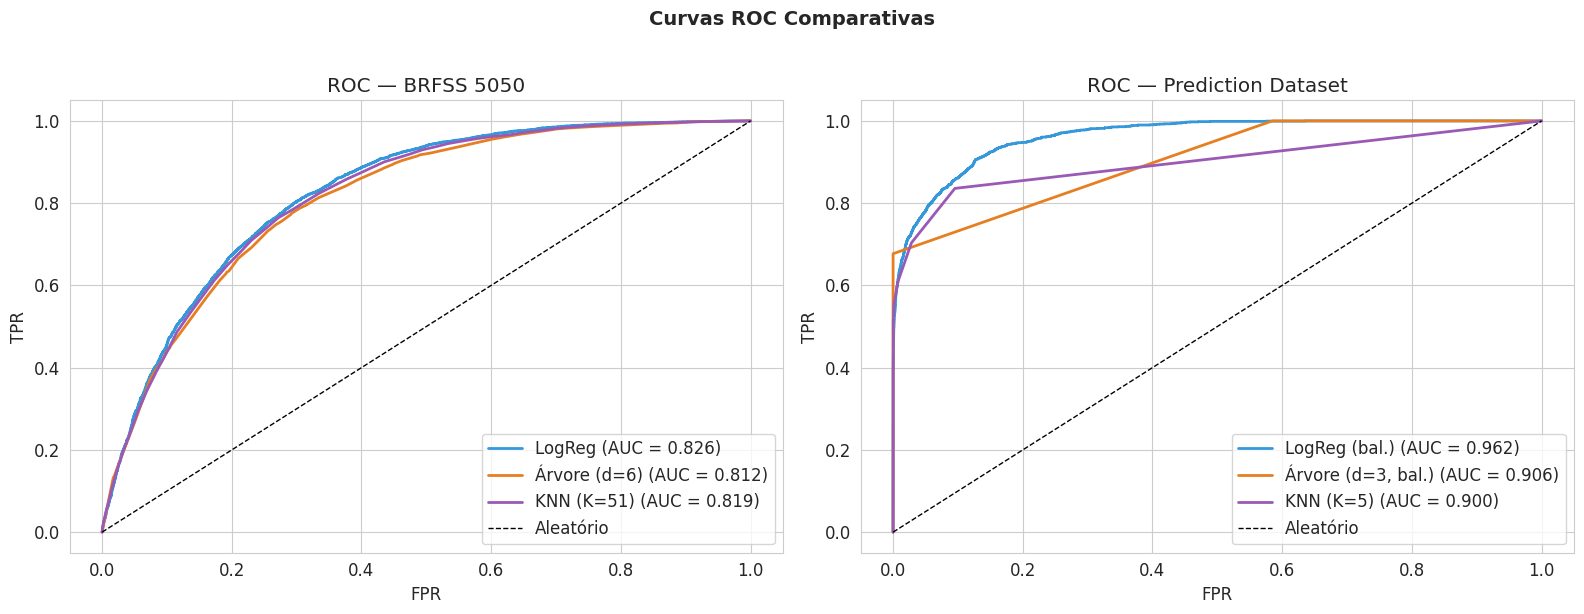

In [35]:
# Curvas ROC: um gráfico por base
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BRFSS
from sklearn.metrics import roc_curve, auc
for nome, y_prob, cor in [
    ('LogReg', y_prob_logreg_brfss_t, '#3498db'),
    (f'Árvore (d={melhor_depth_brfss})', y_prob_tree_brfss_t, '#e67e22'),
    (f'KNN (K={melhor_k_brfss})', y_prob_knn_brfss_t, '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_teste_brfss, y_prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{nome} (AUC = {auc(fpr, tpr):.3f})', color=cor)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
axes[0].set_title('ROC — BRFSS 5050')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend(loc='lower right')

# Prediction
for nome, y_prob, cor in [
    ('LogReg (bal.)', y_prob_logreg_pred_t, '#3498db'),
    (f'Árvore (d={melhor_depth_pred}, bal.)', y_prob_tree_pred_t, '#e67e22'),
    (f'KNN (K={melhor_k_pred})', y_prob_knn_pred_t, '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_teste_pred, y_prob)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{nome} (AUC = {auc(fpr, tpr):.3f})', color=cor)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
axes[1].set_title('ROC — Prediction Dataset')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

fig.suptitle('Curvas ROC Comparativas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'curvas_roc_comparativas.png'), dpi=150, bbox_inches='tight')
plt.show()


**Leitura das ROCs:** a AUC é uma métrica independente de limiar. Quanto mais próxima de 1, melhor a separação. Espera-se que o Prediction apresente AUC mais alta — consequência direta de HbA1c/glicemia. O BRFSS atinge AUC razoável mesmo sem dados laboratoriais, apenas com indicadores comportamentais e clínicos autorrelatados.

### 6.4 Validação cruzada 5-fold

Validação Cruzada 5-fold (F1 ponderado no BRFSS; F1 classe 1 no Prediction)
BRFSS LogReg                   média=0.7463  desvio=0.0054
BRFSS Árvore                   média=0.7361  desvio=0.0049
BRFSS KNN                      média=0.7383  desvio=0.0051
Pred LogReg (bal.)             média=0.5692  desvio=0.0048
Pred Árvore (bal.)             média=0.7990  desvio=0.0048
Pred KNN                       média=0.7236  desvio=0.0063


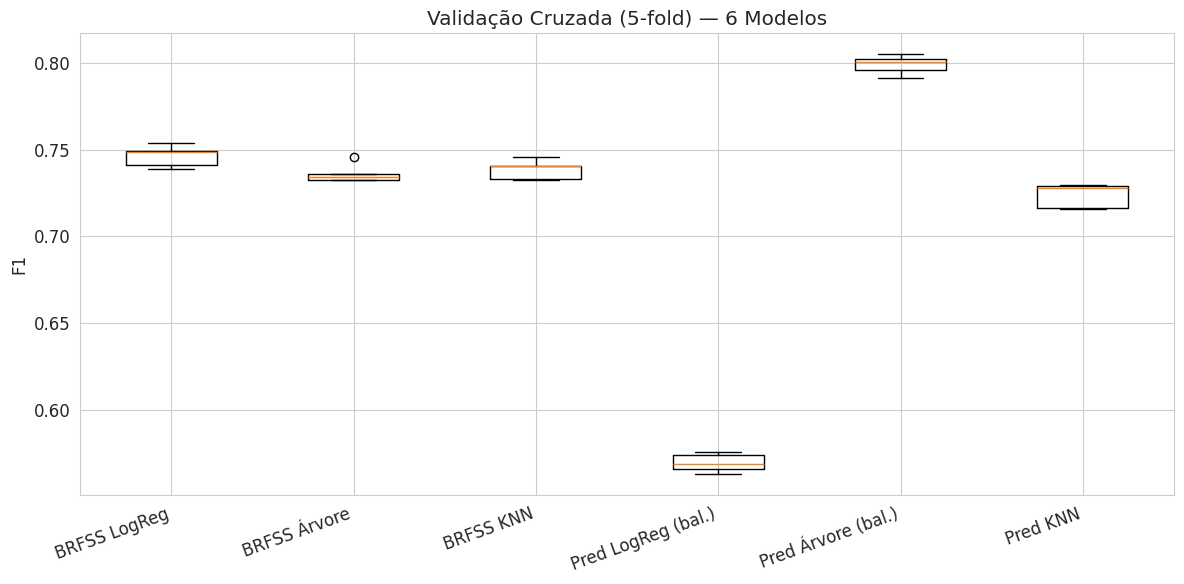

In [36]:
# Validação cruzada (5-fold) no conjunto de treino — só para os modelos finais
# Usamos F1 ponderado para comparar BRFSS (equilibrado) e F1 da classe 1 no Prediction
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Validação Cruzada 5-fold (F1 ponderado no BRFSS; F1 classe 1 no Prediction)')
print('=' * 75)

resultados_cv = {}
for nome, pipe, X_tr, y_tr, scoring in [
    ('BRFSS LogReg', pipe_logreg_brfss, X_treino_brfss, y_treino_brfss, 'f1_weighted'),
    (f'BRFSS Árvore', pipe_tree_brfss, X_treino_brfss, y_treino_brfss, 'f1_weighted'),
    (f'BRFSS KNN', pipe_knn_brfss, X_treino_brfss, y_treino_brfss, 'f1_weighted'),
    ('Pred LogReg (bal.)', pipe_logreg_pred, X_treino_pred, y_treino_pred, 'f1'),
    (f'Pred Árvore (bal.)', pipe_tree_pred, X_treino_pred, y_treino_pred, 'f1'),
    (f'Pred KNN', pipe_knn_pred, X_treino_pred, y_treino_pred, 'f1'),
]:
    scores = cross_val_score(pipe, X_tr, y_tr, cv=skf, scoring=scoring, n_jobs=-1)
    resultados_cv[nome] = scores
    print(f'{nome:30s} média={scores.mean():.4f}  desvio={scores.std():.4f}')

# Boxplot
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(list(resultados_cv.values()), labels=list(resultados_cv.keys()))
ax.set_ylabel('F1')
ax.set_title('Validação Cruzada (5-fold) — 6 Modelos')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'validacao_cruzada_6_modelos.png'), dpi=150, bbox_inches='tight')
plt.show()


**Leitura da CV:** baixa variância entre folds indica modelo estável. Modelos com distribuição muito dispersa são sensíveis à amostra de treino — sinal de alerta em aplicação clínica.

---


## 7. Interpretação dos Resultados

Três lentes complementares:

- **Coeficientes da Regressão Logística**: direção e tamanho do efeito de cada feature no log-odds de diabetes. Interpretação mais transparente.
- **Feature Importance da Árvore**: contribuição relativa nas decisões (quantos splits ganham ao usar cada feature).
- **SHAP (árvore)**: atribuição individual por amostra, com sinal — responde "por que esse paciente foi classificado assim".

### 7.1 Coeficientes da Regressão Logística

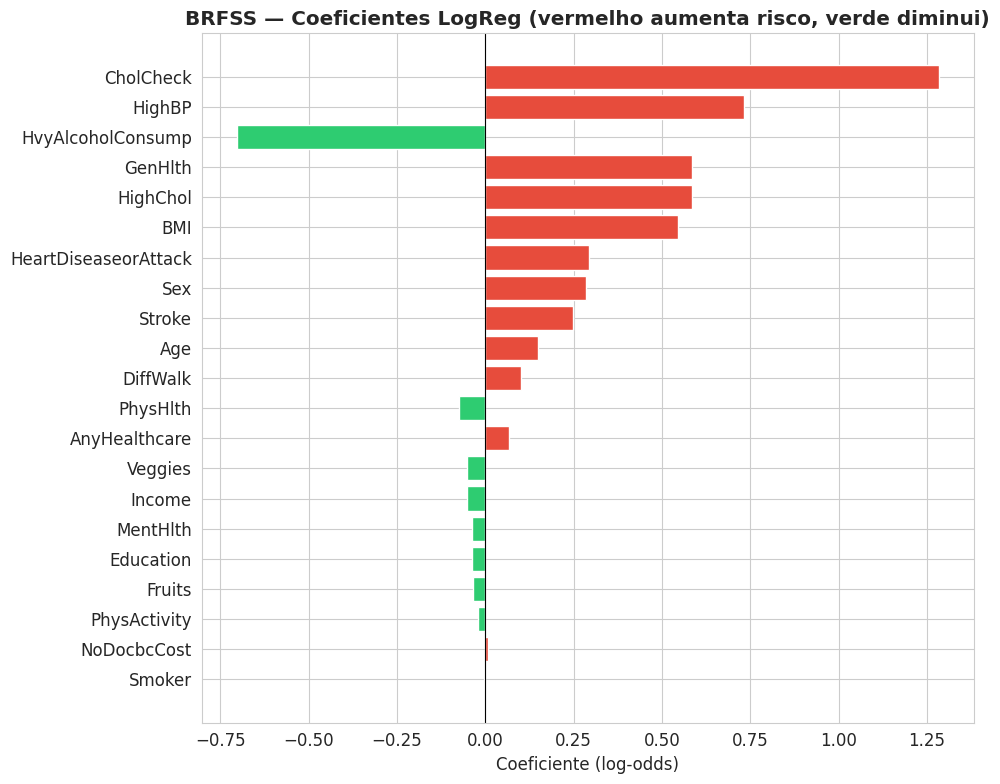

In [37]:
# Coeficientes LogReg BRFSS
feature_names_brfss = cols_continuas_brfss + cols_int_brfss  # na ordem do ColumnTransformer
coef_brfss = pipe_logreg_brfss.named_steps['modelo'].coef_[0]
df_coef_brfss = pd.DataFrame({'feature': feature_names_brfss, 'coef': coef_brfss})
df_coef_brfss['abs_coef'] = df_coef_brfss['coef'].abs()
df_coef_brfss = df_coef_brfss.sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#e74c3c' if c > 0 else '#2ecc71' for c in df_coef_brfss['coef']]
ax.barh(df_coef_brfss['feature'], df_coef_brfss['coef'], color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('BRFSS — Coeficientes LogReg (vermelho aumenta risco, verde diminui)', fontweight='bold')
ax.set_xlabel('Coeficiente (log-odds)')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_coef_logreg.png'), dpi=150, bbox_inches='tight')
plt.show()


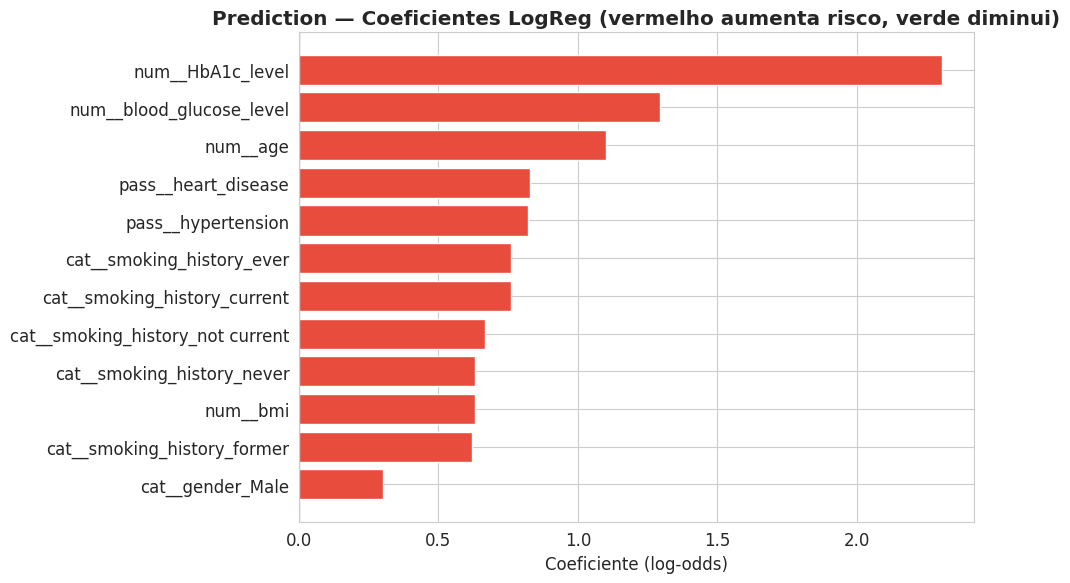

In [38]:
# Coeficientes LogReg Prediction — precisamos dos nomes pós-OneHot
nomes_pred = pipe_logreg_pred.named_steps['preproc'].get_feature_names_out()
coef_pred = pipe_logreg_pred.named_steps['modelo'].coef_[0]
df_coef_pred = pd.DataFrame({'feature': nomes_pred, 'coef': coef_pred})
df_coef_pred['abs_coef'] = df_coef_pred['coef'].abs()
df_coef_pred = df_coef_pred.sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#e74c3c' if c > 0 else '#2ecc71' for c in df_coef_pred['coef']]
ax.barh(df_coef_pred['feature'], df_coef_pred['coef'], color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Prediction — Coeficientes LogReg (vermelho aumenta risco, verde diminui)', fontweight='bold')
ax.set_xlabel('Coeficiente (log-odds)')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'pred_coef_logreg.png'), dpi=150, bbox_inches='tight')
plt.show()


**Observação chave:** nos coeficientes do Prediction, `HbA1c_level` e `blood_glucose_level` dominam a magnitude — como esperado por seu peso clínico. No BRFSS, o risco fica distribuído entre `GenHlth`, `HighBP`, `BMI`, `Age`, `HighChol` — nenhum isolado é tão preditivo.

### 7.2 Feature Importance das Árvores

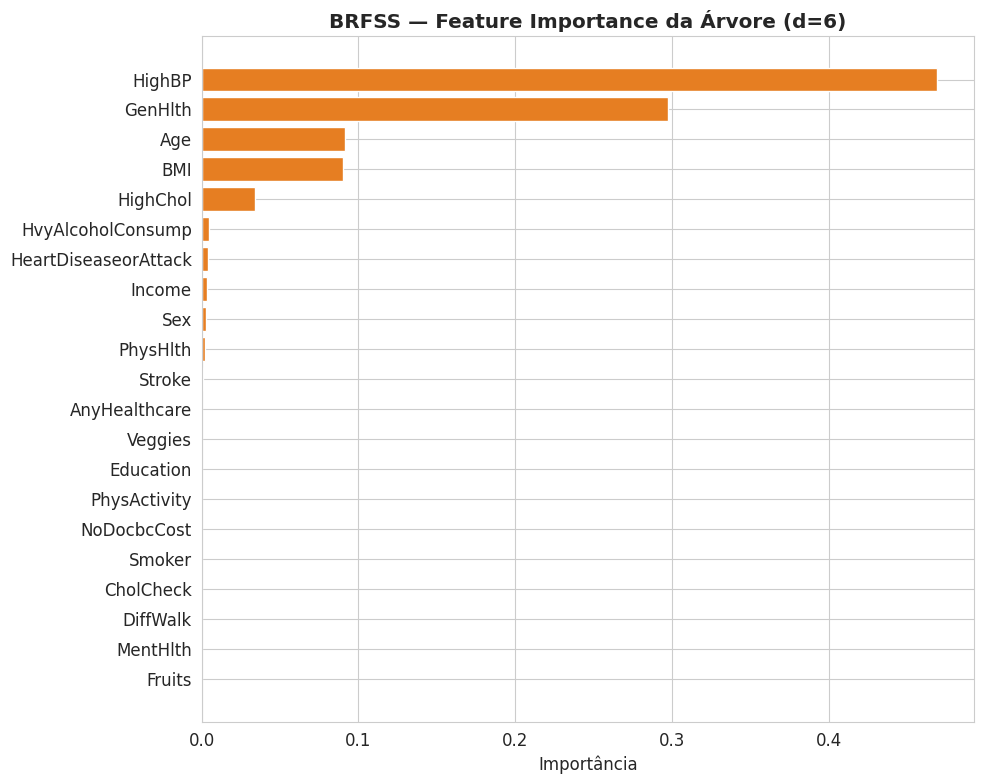

In [39]:
# Feature importance BRFSS
imp_brfss = pipe_tree_brfss.named_steps['modelo'].feature_importances_
df_imp_brfss = pd.DataFrame({'feature': feature_names_brfss, 'importancia': imp_brfss})
df_imp_brfss = df_imp_brfss.sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_imp_brfss['feature'], df_imp_brfss['importancia'], color='#e67e22')
ax.set_title(f'BRFSS — Feature Importance da Árvore (d={melhor_depth_brfss})', fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


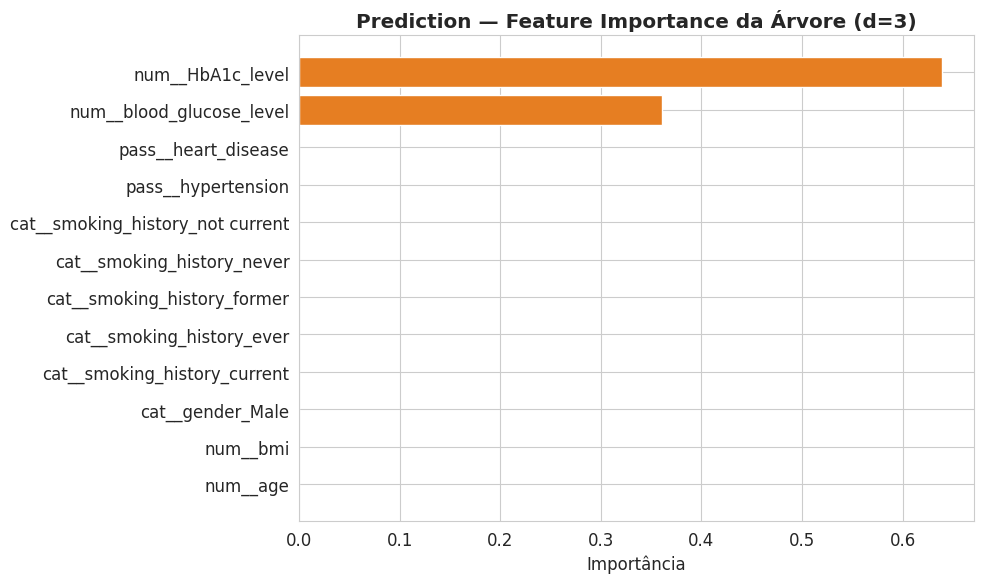

In [40]:
# Feature importance Prediction
imp_pred = pipe_tree_pred.named_steps['modelo'].feature_importances_
df_imp_pred = pd.DataFrame({'feature': nomes_pred, 'importancia': imp_pred})
df_imp_pred = df_imp_pred.sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_imp_pred['feature'], df_imp_pred['importancia'], color='#e67e22')
ax.set_title(f'Prediction — Feature Importance da Árvore (d={melhor_depth_pred})', fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'pred_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


### 7.3 SHAP

SHAP explica predições individuais: para cada amostra, distribui a previsão final entre as features. O summary plot mostra o impacto agregado, preservando o sinal (positivo = puxa para classe diabética).

Para manter o tempo de execução razoável, calculamos SHAP sobre uma **amostra aleatória de 1.000 casos do teste** de cada base.

SHAP summary — BRFSS (classe diabético)


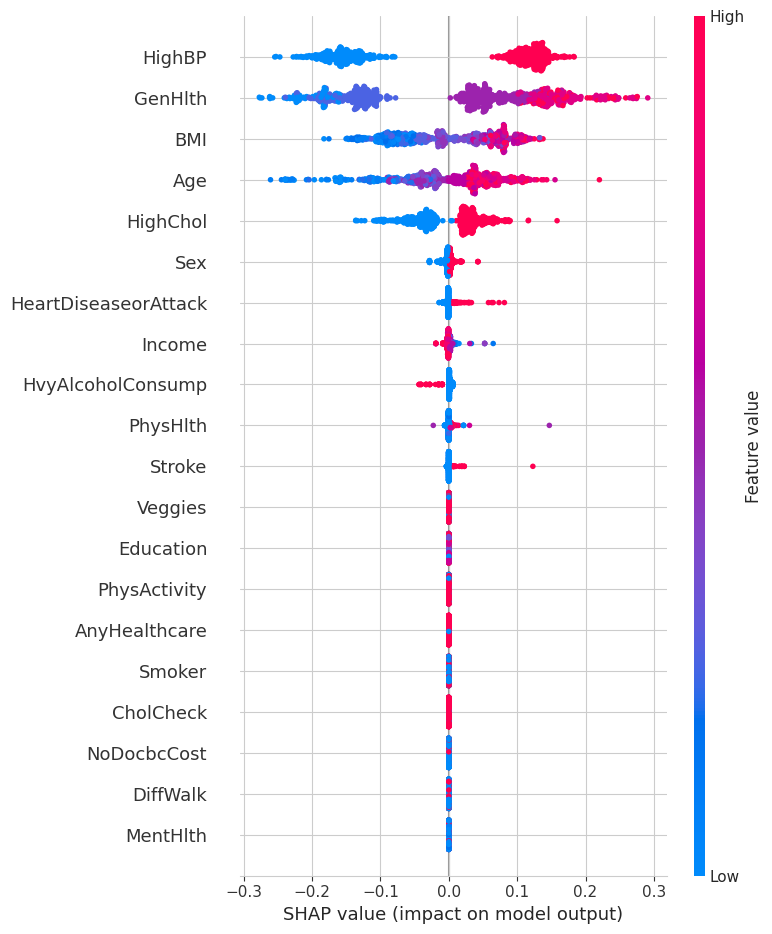

In [41]:
# Precisamos transformar os dados pelo preproc (SHAP recebe a matriz numérica final do modelo)
# --- SHAP BRFSS (árvore) ---
rng_shap = np.random.RandomState(7)
idx_brfss = rng_shap.choice(len(X_teste_brfss), size=min(1000, len(X_teste_brfss)), replace=False)
X_shap_brfss = pipe_tree_brfss.named_steps['preproc'].transform(X_teste_brfss.iloc[idx_brfss])
explainer_brfss = shap.TreeExplainer(pipe_tree_brfss.named_steps['modelo'])
shap_brfss = explainer_brfss.shap_values(X_shap_brfss)

# Em árvores sklearn, shap_values pode vir como lista (uma por classe) ou array 3D — normalizamos
if isinstance(shap_brfss, list):
    shap_values_pos = shap_brfss[1]
elif shap_brfss.ndim == 3:
    shap_values_pos = shap_brfss[:, :, 1]
else:
    shap_values_pos = shap_brfss

print('SHAP summary — BRFSS (classe diabético)')
shap.summary_plot(shap_values_pos, X_shap_brfss,
                  feature_names=np.array(feature_names_brfss), show=False)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()


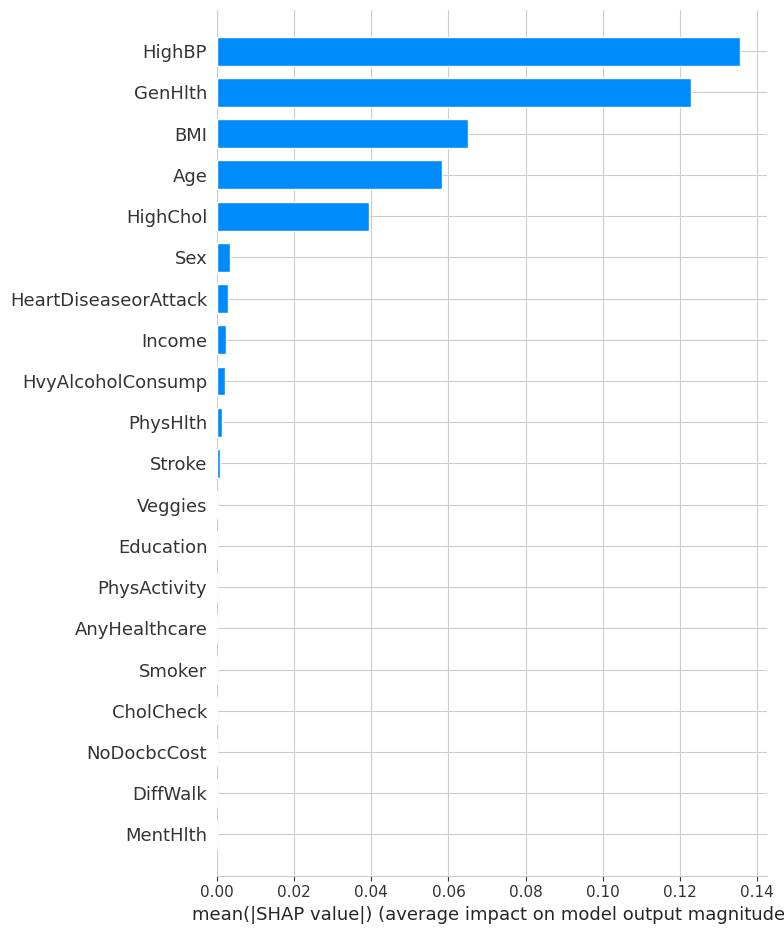

In [42]:
# SHAP bar plot BRFSS
shap.summary_plot(shap_values_pos, X_shap_brfss,
                  feature_names=np.array(feature_names_brfss),
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'brfss_shap_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


SHAP summary — Prediction (classe diabético)


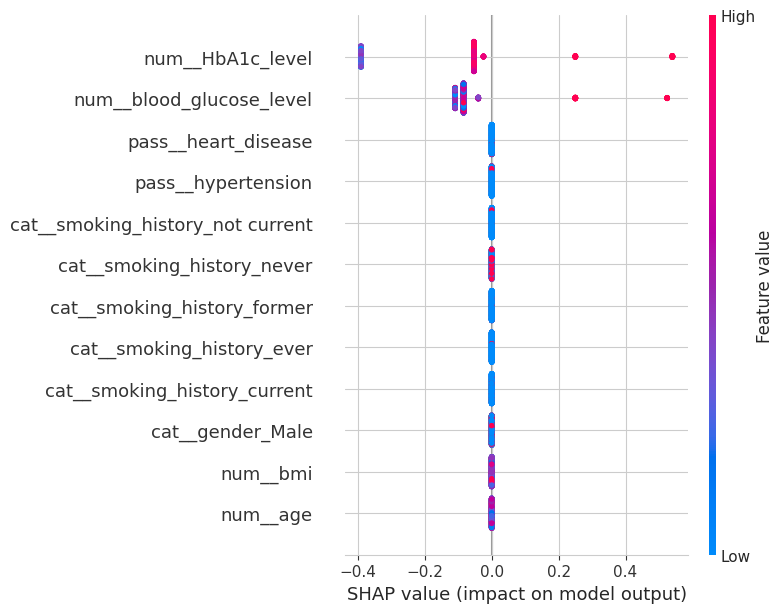

In [43]:
# --- SHAP Prediction (árvore) ---
idx_pred = rng_shap.choice(len(X_teste_pred), size=min(1000, len(X_teste_pred)), replace=False)
X_shap_pred = pipe_tree_pred.named_steps['preproc'].transform(X_teste_pred.iloc[idx_pred])
explainer_pred = shap.TreeExplainer(pipe_tree_pred.named_steps['modelo'])
shap_pred = explainer_pred.shap_values(X_shap_pred)
if isinstance(shap_pred, list):
    shap_values_pos_p = shap_pred[1]
elif shap_pred.ndim == 3:
    shap_values_pos_p = shap_pred[:, :, 1]
else:
    shap_values_pos_p = shap_pred

print('SHAP summary — Prediction (classe diabético)')
shap.summary_plot(shap_values_pos_p, X_shap_pred,
                  feature_names=np.array(nomes_pred), show=False)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'pred_shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()


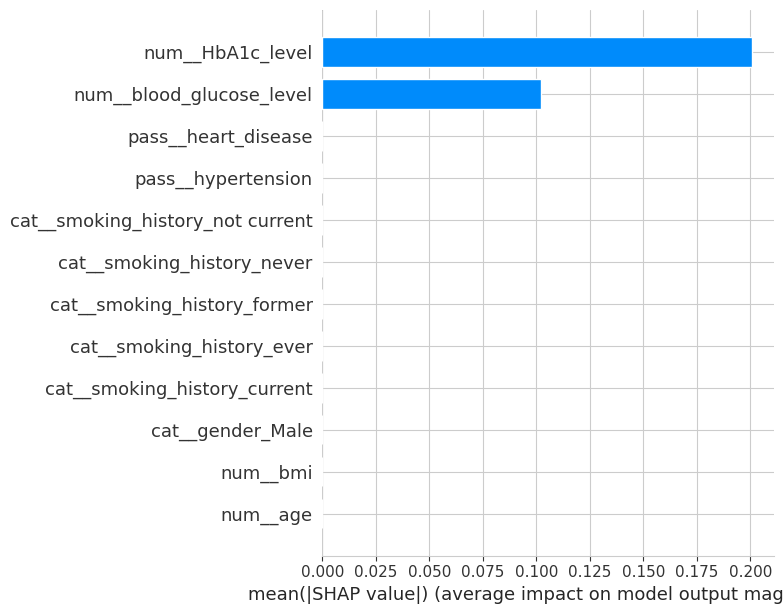

In [44]:
# SHAP bar plot Prediction
shap.summary_plot(shap_values_pos_p, X_shap_pred,
                  feature_names=np.array(nomes_pred),
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'pred_shap_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### 7.4 Comparação dos insights entre as duas bases

Olhando as três lentes (coeficientes, feature importance e SHAP), chegamos aos seguintes destaques:

- **No BRFSS**, os fatores mais influentes são `GenHlth` (percepção de saúde), `HighBP`, `BMI`, `Age`, `HighChol` e `DiffWalk`. É um **retrato multifatorial**: hipertensão, colesterol, obesidade e idade combinam para formar o risco.
- **No Prediction**, `HbA1c_level` e `blood_glucose_level` dominam de forma isolada. As demais features (`bmi`, `age`, `hypertension`) contribuem marginalmente.

**Interpretação:** a BRFSS aprende a identificar **quem tem perfil de risco** (hábitos, comorbidades, contexto social), enquanto o Prediction aprende a identificar **quem já tem sinais bioquímicos**. Isso tem implicação clínica: BRFSS é útil para rastreio de população geral em atenção primária; Prediction é útil para triagem em exames laboratoriais.

---


## 8. Discussão Crítica

### Qual base teve melhor desempenho?

Olhando Recall e F1 da classe "diabético", a base **Prediction** produz modelos com Recall visivelmente mais alto do que a BRFSS — consequência direta do peso de HbA1c e glicemia. Isso era esperado: **features de laboratório medem o próprio desfecho**; features comportamentais e sociais são proxies.

Mesmo assim, a BRFSS atinge desempenho respeitável sem qualquer dado laboratorial, o que abre um caso de uso importante: **rastreio populacional em contextos onde não há acesso imediato a exames**.

### Comparação com o notebook 02 (Pima Indians)

O notebook anterior obtinha F1-Score em torno de 0,70-0,75 em um dataset de 768 amostras, com 8 features clínicas. As duas novas bases trazem:

- **Mais dados**: 70k e 100k amostras vs. 768 — reduz variância e permite modelos mais estáveis.
- **Mais eixos**: BRFSS cobre comportamento e contexto social; Prediction adiciona HbA1c. Pima tem só clínicas básicas.
- **Melhor desempenho esperado** quando se compara Pima ao Prediction, e desempenho equivalente ou ligeiramente inferior quando comparamos Pima ao BRFSS (onde o sinal é mais indireto).

**Conclusão:** o ganho de features justifica o esforço, principalmente se o objetivo é **identificar risco antes do exame laboratorial**.

### Limitações

**BRFSS:**
- Dados **autorrelatados** em entrevista telefônica — há viés de resposta (subdeclaração de hábitos nocivos, p. ex.).
- Limitado aos Estados Unidos (2015); generalizar para outras populações exige revalidação.
- Não há marcadores bioquímicos — o modelo só enxerga sintomas e contexto.

**Prediction:**
- Distribuição 91/9 — o modelo tende a errar com custo assimétrico. Mitigamos com `class_weight='balanced'` na LogReg e na Árvore, mas o KNN ainda sofre.
- O site de origem (Kaggle) indica que os dados podem ter sido parcialmente sintetizados; não há documentação clínica como no BRFSS.
- Menos features — menos contexto sobre o paciente como pessoa (contexto social ausente).

**Ambos:**
- Não há histórico familiar detalhado, dieta, nível real de atividade física, ou uso de medicação.
- Modelos treinados em uma população não devem ser aplicados cegamente em outra sem revalidação.

### O modelo pode ser usado na prática? Como?

**Sim, como ferramenta de apoio à triagem, não como instrumento de diagnóstico final.** Cenários de uso:

1. **Atenção primária (BRFSS-like):** um questionário estruturado sobre hábitos e histórico pode alimentar um modelo para **priorizar encaminhamento a exames**. Quem for classificado como alto risco é encaminhado para glicemia de jejum/HbA1c; quem for baixo risco entra em acompanhamento regular.
2. **Triagem laboratorial (Prediction-like):** quando já há exames, o modelo pode **integrar HbA1c, glicemia e outras informações** em um score de risco que ajuda o(a) médico(a) a priorizar pacientes que precisam de avaliação detalhada.

### O papel do(a) médico(a)

Reforçando o princípio central: o modelo **nunca substitui** a avaliação clínica. A decisão diagnóstica considera:
- Contexto individual e exame físico.
- Histórico clínico e familiar completo.
- Resultado de exames mais amplos do que qualquer base estruturada captura.
- Julgamento clínico frente a casos atípicos ou comorbidades múltiplas.

O modelo é um **acelerador**: automatiza triagem, prioriza casos e sinaliza padrões. A palavra final é sempre médica — e deve ser.

---

*Notebook desenvolvido como parte do Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs*
